[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/01_vectors_spaces_and_subspaces/first_principles.ipynb)

# Module 01 — Vectors, Spaces, and Subspaces

## 1. Why This Module Exists

Forces add. Signals add. Probability distributions can be mixed. Images can be brightened.
Four unrelated subjects, one shared algebra: you may add two objects and scale one object, and
what comes out is still an object of the same kind.

A **vector space** is the minimal axiom set that captures exactly that and nothing else. The
payoff is leverage: every theorem proved from the axioms holds at once for arrows, matrices,
polynomials, solutions of a differential equation and layers of a neural network.

The module then asks the only question the axioms leave open. Given a set of vectors, how much
of the space can they reach, how much of the reaching is redundant, and how many numbers does it
take to name a point?

Those three questions are **span**, **linear independence** and **dimension**. Dimension is the
one that needs proof: a space has many different bases, and it is not obvious that they all have
the same size. Theorem 4.2 shows that they do, and everything downstream — rank, nullity,
degrees of freedom, the number of parameters a model really has — rests on it.

## 2. Intuition

Picture $\mathbb{R}^2$. A **subspace** is a set closed under the two operations, so it must be
flat and it must pass through the origin: only $\lbrace 0 \rbrace$, a line through the origin,
or the whole plane.

That is a strong restriction. The line $x + y = 1$ is flat but misses the origin, and the two
quadrants where $xy \ge 0$ contain the origin and survive scaling, yet adding two of their points
can land outside. Both fail, for different reasons.

**Span** is the reaching operation. Starting from a set of vectors, take every linear
combination; the result is always a subspace, and it is the smallest one containing the set.

**Independence** is the absence of waste. A list is independent when no vector is reachable from
the others, so removing any one of them shrinks the span.

A **basis** is a list that is both: it reaches everything and wastes nothing. Its length is the
**dimension** — the number of coordinates a point needs. The picture to hold is that a subspace
is a flat sheet through the origin, and its dimension is how many independent directions you can
walk without leaving it.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single random
generator used everywhere below, and prints the machine epsilon that later residual claims are
measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported later is quoted as a multiple of this number.

The next cell draws the picture described above. The left panel shows the subspace
$L = \operatorname{span}\lbrace (2,1) \rbrace$ against the affine line $x + y = 1$, which is flat
but misses the origin. The right panel shows $Q = \lbrace (x,y) \mid xy \ge 0 \rbrace$, which
contains the origin and survives scaling but is not closed under addition:
$(2,1) + (-1,-2) = (1,-1)$ leaves it.

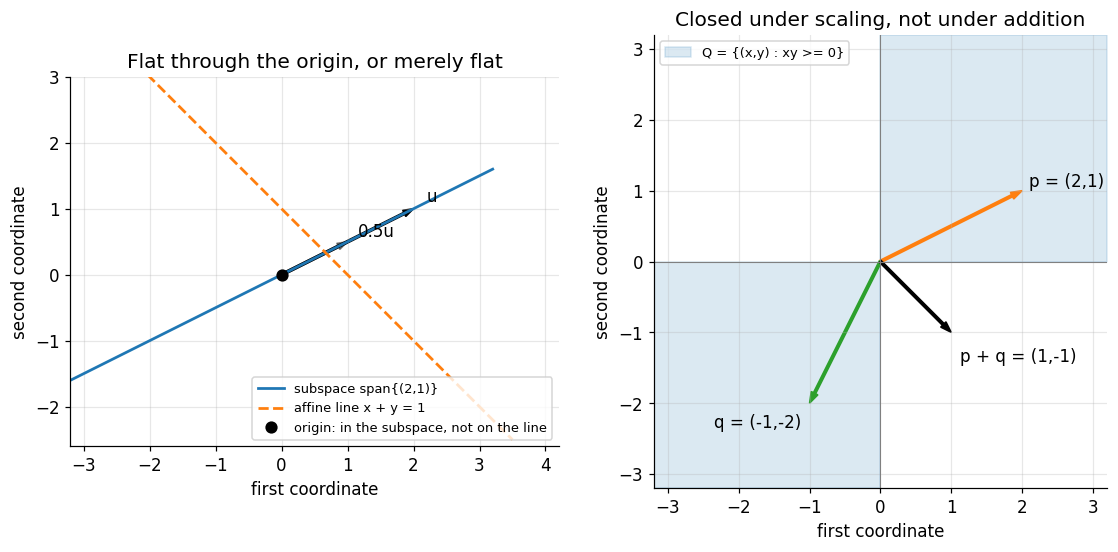

left panel : is the origin on the line x + y = 1? False
right panel: p in Q? True   q in Q? True   p + q in Q? False


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.0))

# --- left panel: subspace versus affine set ------------------------------
ax = axes[0]
t = np.linspace(-1.6, 1.6, 200)
d = np.array([2.0, 1.0])
line = np.outer(t, d)
ax.plot(line[:, 0], line[:, 1], lw=1.8, label="subspace span{(2,1)}")

s = np.linspace(-2.5, 3.5, 200)
ax.plot(s, 1.0 - s, lw=1.8, ls="--", label="affine line x + y = 1")

u = np.array([2.0, 1.0])
w = 0.5 * u
ax.arrow(0, 0, u[0], u[1], width=0.035, length_includes_head=True, color="k")
ax.arrow(0, 0, w[0], w[1], width=0.035, length_includes_head=True, color="k", alpha=0.45)
ax.plot([0.0], [0.0], "ko", ms=7, label="origin: in the subspace, not on the line")
ax.annotate("u", u * 1.10)
ax.annotate("0.5u", w * 1.15)
ax.set_xlim(-3.2, 4.2)
ax.set_ylim(-2.6, 3.0)
ax.set_aspect("equal")
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")
ax.set_title("Flat through the origin, or merely flat")
ax.legend(fontsize=8.5, loc="lower right")

# --- right panel: scaling closed, addition not ---------------------------
ax = axes[1]
ax.fill_between([0.0, 3.2], [0.0, 0.0], [3.2, 3.2], alpha=0.16, color="C0")
ax.fill_between([-3.2, 0.0], [-3.2, -3.2], [0.0, 0.0], alpha=0.16, color="C0",
                label="Q = {(x,y) : xy >= 0}")
p = np.array([2.0, 1.0])
q = np.array([-1.0, -2.0])
ax.arrow(0, 0, p[0], p[1], width=0.035, length_includes_head=True, color="C1")
ax.arrow(0, 0, q[0], q[1], width=0.035, length_includes_head=True, color="C2")
ax.arrow(0, 0, (p + q)[0], (p + q)[1], width=0.035, length_includes_head=True, color="k")
ax.annotate("p = (2,1)", p * 1.05)
ax.annotate("q = (-1,-2)", q + np.array([-1.35, -0.35]))
ax.annotate("p + q = (1,-1)", (p + q) + np.array([0.12, -0.42]))
ax.axhline(0.0, lw=0.7, color="0.5")
ax.axvline(0.0, lw=0.7, color="0.5")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.set_aspect("equal")
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")
ax.set_title("Closed under scaling, not under addition")
ax.legend(fontsize=8.5, loc="upper left")

plt.tight_layout()
plt.show()

print("left panel : is the origin on the line x + y = 1?", 0.0 + 0.0 == 1.0)
print("right panel: p in Q?", 2.0 * 1.0 >= 0, "  q in Q?", (-1.0) * (-2.0) >= 0,
      "  p + q in Q?", 1.0 * (-1.0) >= 0)

The left panel makes the origin the discriminator: the solid line contains it and is a subspace,
the dashed line does not and is not.

The right panel isolates the other failure mode. Every scalar multiple of a point of $Q$ stays in
$Q$, yet the sum of the two arrows lands in the fourth quadrant. **Closure under scaling alone is
not enough**; Theorem 4.3 requires both operations.

## 3. Definitions

Throughout, $\mathbb{F}$ is a field — in practice $\mathbb{R}$ or $\mathbb{C}$ — and $V$ is a set
carrying an addition $V \times V \to V$ and a scalar multiplication
$\mathbb{F} \times V \to V$. Vectors are columns, matrices are $m \times n$ with $m$ rows, and
$A^\top$ is the transpose. The repository-wide conventions are fixed in
[the notation register](../../docs/notation.md).

### Definition 3.1 — Vector space

$V$ is a **vector space over $\mathbb{F}$** when, for all $u, v, w \in V$ and all
$\alpha, \beta \in \mathbb{F}$:

1. $u + v = v + u$;
2. $(u + v) + w = u + (v + w)$;
3. there is $0 \in V$ with $v + 0 = v$;
4. for each $v$ there is $-v \in V$ with $v + (-v) = 0$;
5. $1 \cdot v = v$;
6. $\alpha(u + v) = \alpha u + \alpha v$;
7. $(\alpha + \beta) v = \alpha v + \beta v$;
8. $\alpha(\beta v) = (\alpha\beta) v$.

Nothing else is assumed. There is no length, no angle, no notion of one vector being larger than
another; those arrive later with an inner product.

### Definition 3.2 — Subspace

A subset $U \subseteq V$ is a **subspace** when $U$ is itself a vector space under the addition
and scalar multiplication inherited from $V$.

Theorem 4.3 reduces this to two closure conditions, so no one ever checks eight axioms twice.

### Definition 3.3 — Linear combination and span

A **linear combination** of $v_1, \dots, v_k \in V$ is any vector
$\alpha_1 v_1 + \dots + \alpha_k v_k$ with $\alpha_i \in \mathbb{F}$.

The **span** of a set $S \subseteq V$ is the set of all linear combinations of finitely many
elements of $S$:

$$
\operatorname{span}(S) = \lbrace \alpha_1 v_1 + \cdots + \alpha_k v_k \;:\; k \in \mathbb{N},\; v_i \in S,\; \alpha_i \in \mathbb{F} \rbrace .
$$

By convention $\operatorname{span}(\emptyset) = \lbrace 0 \rbrace$, which is what makes the empty
list a basis of the zero space.

### Definition 3.4 — Linear independence

A finite list $v_1, \dots, v_k$ is **linearly independent** when

$$
\alpha_1 v_1 + \dots + \alpha_k v_k = 0 \quad \Longrightarrow \quad \alpha_1 = \dots = \alpha_k = 0 .
$$

An infinite set is independent when every finite sublist is. A list that is not independent is
**dependent**, and then some vector in it lies in the span of the others.

### Definition 3.5 — Basis, finite-dimensional

A list $B$ in $V$ is a **basis** when it is linearly independent and $\operatorname{span}(B) = V$.

$V$ is **finite-dimensional** when some finite list spans it, and **infinite-dimensional**
otherwise.

### Definition 3.6 — Dimension

Let $V$ be finite-dimensional. The **dimension** $\dim V$ is the length of *some* basis of $V$.

This definition is provisional until Theorem 4.2, which proves that all bases of $V$ have the
same length, so that the choice of basis does not matter. Nothing before Proof 5.2 uses the
word *dimension*, so the argument is not circular.

### Definition 3.7 — Sum and direct sum

For subspaces $U, W \subseteq V$,

$$
U + W = \lbrace u + w \mid u \in U,\; w \in W \rbrace .
$$

The sum is **direct**, written $U \oplus W$, when in addition $U \cap W = \lbrace 0 \rbrace$.

The union $U \cup W$ is almost never a subspace; Proposition 4.12 says exactly when it is.

### Definition 3.8 — Affine set, affine combination, affine hull

An **affine set** is a translated subspace $A = v_0 + U = \lbrace v_0 + u \mid u \in U \rbrace$.

An **affine combination** of $v_1, \dots, v_k$ is $\sum_i \alpha_i v_i$ with $\sum_i \alpha_i = 1$.
The **affine hull** $\operatorname{aff}(S)$ is the set of all affine combinations of elements of
$S$.

An affine set contains the origin if and only if it is a subspace.

### Definition 3.9 — Convex set, convex hull, barycentric coordinates

$C \subseteq V$ is **convex** when $\theta u + (1-\theta) v \in C$ for all $u, v \in C$ and
$\theta \in [0,1]$.

A **convex combination** is an affine combination with all $\alpha_i \ge 0$, and the **convex
hull** $\operatorname{conv}(S)$ is the set of all convex combinations of elements of $S$.

If $p_0, \dots, p_k$ are **affinely independent** — meaning $p_1 - p_0, \dots, p_k - p_0$ are
linearly independent — then every $x \in \operatorname{aff}(p_0, \dots, p_k)$ has a unique
representation $x = \sum_i \alpha_i p_i$ with $\sum_i \alpha_i = 1$. The coefficients
$(\alpha_0, \dots, \alpha_k)$ are the **barycentric coordinates** of $x$, and $x$ lies in the
convex hull exactly when all of them are non-negative.

### Definition 3.10 — Linear map, isomorphism

A map $T : V \to W$ between vector spaces over the same $\mathbb{F}$ is **linear** when
$T(\alpha u + v) = \alpha T(u) + T(v)$ for all $u, v \in V$ and $\alpha \in \mathbb{F}$.

A linear bijection is an **isomorphism**, and $V \cong W$ means an isomorphism exists.

Only the definition is needed here. The theory of linear maps is
[Module 02](../02_linear_maps_and_matrix_transformations/first_principles.ipynb).

### Definition 3.11 — Dual space, dual basis

A **linear functional** is a linear map $f : V \to \mathbb{F}$. The set of all of them is the
**dual space** $V^{\ast}$, itself a vector space under pointwise operations.

Given a basis $e_1, \dots, e_n$ of $V$, the **dual basis** $\varphi_1, \dots, \varphi_n$ of
$V^{\ast}$ is defined by

$$
\varphi_i(e_j) = \delta_{ij} .
$$

Theorem 4.10 proves this list really is a basis of $V^{\ast}$.

### Definition 3.12 — Annihilator

For a subspace $U \subseteq V$, the **annihilator** is

$$
U^{0} = \lbrace f \in V^{\ast} \mid f(u) = 0 \ \text{ for all } u \in U \rbrace \subseteq V^{\ast} .
$$

For a subspace $S \subseteq V^{\ast}$, the **pre-annihilator** is
${}^{0}S = \lbrace v \in V \mid f(v) = 0 \ \text{ for all } f \in S \rbrace \subseteq V$.

### Definition 3.13 — Quotient space and codimension

For a subspace $U \subseteq V$ and $v \in V$, the **coset** is
$v + U = \lbrace v + u \mid u \in U \rbrace$, and the **quotient space** is

$$
V / U = \lbrace v + U \mid v \in V \rbrace ,
$$

with operations $(v_1 + U) + (v_2 + U) = (v_1 + v_2) + U$ and
$\alpha(v + U) = (\alpha v) + U$. The **codimension** of $U$ is
$\operatorname{codim} U = \dim(V/U)$.

Two vectors name the same coset exactly when their difference lies in $U$, so a quotient is the
formal way of saying "ignore the $U$ directions".

### Definition 3.14 — Coordinate map, column space, null space

For a basis $B = (e_1, \dots, e_n)$ of $V$, the **coordinate map** is

$$
\phi_B\left( \sum_{i=1}^{n} \alpha_i e_i \right) = (\alpha_1, \dots, \alpha_n)^\top \in \mathbb{F}^n .
$$

For $A \in \mathbb{F}^{m \times n}$, the **column space** $\operatorname{Col}(A)$ is the span of
the columns, the **row space** $\operatorname{Row}(A)$ is the span of the rows, the **null space**
is $\operatorname{Null}(A) = \lbrace x \mid Ax = 0 \rbrace$, and
$\operatorname{rank}(A) = \dim \operatorname{Col}(A)$.

### Definition 3.15 — Tensor product

For finite-dimensional $V$ and $W$ over $\mathbb{F}$, the **tensor product** $V \otimes W$ is the
vector space spanned by symbols $v \otimes w$ subject only to bilinearity:

$$
(\alpha v_1 + v_2) \otimes w = \alpha (v_1 \otimes w) + v_2 \otimes w, \qquad
v \otimes (\alpha w_1 + w_2) = \alpha (v \otimes w_1) + v \otimes w_2 .
$$

If $e_1, \dots, e_n$ is a basis of $V$ and $f_1, \dots, f_m$ a basis of $W$, then
$\lbrace e_i \otimes f_j \rbrace$ is a basis of $V \otimes W$, so
$\dim(V \otimes W) = nm$. Concretely $\mathbb{R}^n \otimes \mathbb{R}^m \cong \mathbb{R}^{n \times m}$
with $v \otimes w = v w^\top$.

## 4. Main Results

Theorem 4.1 is the engine of the whole module. Theorem 4.2 — the result the module is named
after, since without it the word *dimension* means nothing — is deduced from it in four lines.

Theorems 4.3 to 4.6 are the working tools: how to recognise a subspace, how to build a basis,
and how dimensions behave under intersection and sum. Theorems 4.7 to 4.10 push the same
bookkeeping through matrices, quotients, coordinates and duals. Theorem 4.11 is the convex
counterpart, Proposition 4.12 records the standard trap, and Theorem 4.13 says what survives in
infinite dimensions.

### Theorem 4.1 — Steinitz exchange lemma

Let $V$ be a vector space over $\mathbb{F}$, let $v_1, \dots, v_m$ be linearly independent in
$V$, and let $w_1, \dots, w_n$ span $V$. Then

$$
m \le n ,
$$

and after reordering the $w_j$, the list $v_1, \dots, v_m, w_{m+1}, \dots, w_n$ still spans $V$.

**Hypotheses.** Independence of the $v_i$ is what forbids the exchange from stalling: it
guarantees that at every step the new vector needs a genuine $w$ to express it. The spanning
hypothesis on the $w_j$ is what makes an expression available in the first place. Both lists
must be finite; Theorem 4.13 is the substitute when they are not.

Proved as Proof 5.1.

### Theorem 4.2 — Invariance of dimension

Let $V$ be a finite-dimensional vector space. Then every basis of $V$ is finite, and any two
bases of $V$ have the same length. Consequently

$$
\boxed{\dim V \ \text{ is well defined}}
$$

and Definition 3.6 no longer depends on a choice.

**Interpretation.** Meaning: the number of independent directions in a space is a property of the
space, not of the observer's coordinate system. Consequence: rank, nullity, codimension, degrees
of freedom and "number of free parameters" are all legitimate invariants, and two spaces with
different dimensions cannot be isomorphic.

**Hypotheses.** Finite-dimensionality. Over an infinite-dimensional space all bases still have
the same cardinality, but the proof needs Theorem 4.13 and cardinal arithmetic rather than
Theorem 4.1.

Proved as Proof 5.2.

### Theorem 4.3 — Subspace criterion

Let $U \subseteq V$. The following are equivalent.

1. $U$ is a subspace of $V$.
2. $U \neq \emptyset$, and $u + v \in U$ and $\alpha u \in U$ for all $u, v \in U$,
   $\alpha \in \mathbb{F}$.
3. $0 \in U$, and $\alpha u + v \in U$ for all $u, v \in U$ and $\alpha \in \mathbb{F}$.

**Hypotheses.** Non-emptiness in (2) cannot be dropped: the empty set is closed under both
operations vacuously and is not a subspace, because axiom 3 of Definition 3.1 demands a zero
vector. Closure under scaling alone is also not enough — the set $\lbrace (x,y) \mid xy \ge 0 \rbrace$
of Section 2 satisfies it and fails (2), and Section 7.3 runs the failure.

Proved as Proof 5.3.

### Theorem 4.4 — Basis extension, basis extraction, complements

Let $V$ be finite-dimensional.

1. Every linearly independent list in $V$ extends to a basis of $V$.
2. Every spanning list of $V$ contains a basis of $V$.
3. Every subspace $U \subseteq V$ has a complement: a subspace $W$ with $V = U \oplus W$.

**Hypotheses.** Finite-dimensionality is used only to make the extension terminate; with
Theorem 4.13 all three statements survive in general. The complement in (3) is never unique
unless $U$ is $\lbrace 0 \rbrace$ or $V$.

Proved as Proof 5.4.

### Theorem 4.5 — Dimension of a subspace

Let $V$ be finite-dimensional and $U \subseteq V$ a subspace. Then $U$ is finite-dimensional,

$$
\dim U \le \dim V ,
$$

and $\dim U = \dim V$ holds if and only if $U = V$.

**Hypotheses.** Finite-dimensionality of $V$ is essential for the equality clause. In
$V = \mathbb{R}^{\mathbb{N}}$ the proper subspace of sequences with finitely many non-zero terms
has the same (infinite) dimension as a suitable proper superspace, so "same dimension implies
equal" fails outright.

Proved as Proof 5.5.

### Theorem 4.6 — Grassmann dimension formula and the direct-sum criterion

Let $U, W$ be finite-dimensional subspaces of $V$. Then

$$
\boxed{\dim(U + W) + \dim(U \cap W) = \dim U + \dim W}
$$

Moreover the following are equivalent: $V = U \oplus W$; every $v \in V$ is $u + w$ with
$u \in U$, $w \in W$ in exactly one way; and $V = U + W$ with $\dim V = \dim U + \dim W$.

**Interpretation.** Meaning: dimensions obey inclusion-exclusion, exactly like cardinalities of
finite sets. Consequence: $\dim(U+W) = \dim U + \dim W$ holds only when the two subspaces meet
in the origin alone, which is what makes a direct sum "independent".

**Hypotheses.** Both subspaces finite-dimensional. Section 7.3 runs two coplanar planes in
$\mathbb{R}^3$ where the intersection term is $2$, and the naive additive formula overshoots by
exactly that.

Proved as Proof 5.6.

### Theorem 4.7 — Rank identities for a matrix

Let $A \in \mathbb{F}^{m \times n}$. Then

$$
\dim \operatorname{Row}(A) = \dim \operatorname{Col}(A) = \operatorname{rank}(A),
$$

and

$$
\boxed{\operatorname{rank}(A) + \dim \operatorname{Null}(A) = n}
$$

**Interpretation.** Meaning: the $n$ input directions split into those the matrix destroys and
those it keeps, and nothing is lost in between. Consequence: one linear constraint removes
exactly one dimension, which is why a single homogeneous equation cuts $\mathbb{R}^n$ down to a
hyperplane of dimension $n-1$.

**Hypotheses.** None beyond $A$ being a matrix over a field. Note the count is against $n$, the
number of **columns**; the row count $m$ never appears.

Proved as Proof 5.7. The statement for an abstract linear map is
[Module 02](../02_linear_maps_and_matrix_transformations/first_principles.ipynb); the matrix case
proved here is what the rest of this module and its exercises use.

### Theorem 4.8 — Quotient spaces

Let $U$ be a subspace of $V$. The operations of Definition 3.13 are well defined and make $V/U$
a vector space. If $V$ is finite-dimensional then

$$
\boxed{\dim (V/U) = \dim V - \dim U}
$$

**Interpretation.** Meaning: quotienting deletes exactly the directions inside $U$ and keeps the
rest. Consequence: codimension counts the constraints a subspace imposes, which is why the
kernel of one non-zero linear functional has codimension $1$.

**Hypotheses.** Well-definedness needs $U$ to be a subspace, not merely a subset: the argument
uses $u_1 + u_2 \in U$ and $\alpha u \in U$ at exactly one step each.

Proved as Proof 5.8.

### Theorem 4.9 — Coordinate isomorphism and classification by dimension

Let $V$ be an $n$-dimensional vector space over $\mathbb{F}$ with basis $B$. The coordinate map
$\phi_B$ of Definition 3.14 is an isomorphism, so

$$
\boxed{V \cong \mathbb{F}^n}
$$

Two finite-dimensional spaces over $\mathbb{F}$ are isomorphic if and only if they have the same
dimension.

**Interpretation.** Meaning: up to relabelling there is exactly one vector space of each finite
dimension over each field. Consequence: any theorem proved for $\mathbb{F}^n$ transfers verbatim
to polynomials, matrices, or solution spaces of differential equations, and this is why numerical
software can represent all of them as arrays.

**Hypotheses.** The two spaces must share the same scalar field. $\mathbb{C}$ has dimension $1$
over $\mathbb{C}$ and dimension $2$ over $\mathbb{R}$, so "same dimension" is meaningless until
the field is named.

Proved as Proof 5.9.

### Theorem 4.10 — Dual basis, double dual, annihilators

Let $V$ be $n$-dimensional over $\mathbb{F}$.

1. The dual list $\varphi_1, \dots, \varphi_n$ of Definition 3.11 is a basis of $V^{\ast}$, so
   $\dim V^{\ast} = n$.
2. The evaluation map $\operatorname{ev} : V \to V^{\ast\ast}$, $\operatorname{ev}(v)(f) = f(v)$,
   is an isomorphism, and it uses no choice of basis.
3. For a subspace $U \subseteq V$,

$$
\boxed{\dim U + \dim U^{0} = \dim V}
$$

4. For a subspace $S \subseteq V^{\ast}$, $\dim {}^{0}S = \dim V - \dim S$.

**Interpretation.** Meaning: the annihilator is the exact dual-side record of a subspace, and
part 4 says a system of $r$ independent linear equations cuts down dimension by exactly $r$.
Consequence: the codimension of an intersection of hyperplanes equals the number of independent
functionals defining them, never more.

**Hypotheses.** Finite-dimensionality is essential for part 2. For infinite-dimensional $V$ the
map $\operatorname{ev}$ is still injective but never surjective, which is why reflexivity is a
theorem about specific Banach spaces rather than a fact of algebra.

Proved as Proof 5.10.

### Theorem 4.11 — Caratheodory's theorem

Let $S \subseteq \mathbb{R}^n$ and $x \in \operatorname{conv}(S)$. Then $x$ is a convex
combination of at most $n+1$ points of $S$:

$$
x = \sum_{i=1}^{k} \alpha_i p_i, \qquad p_i \in S, \quad \alpha_i \gt 0, \quad \sum_{i=1}^{k} \alpha_i = 1, \quad k \le n+1 .
$$

**Hypotheses.** The ambient space must be finite-dimensional, and the bound $n+1$ rather than $n$
comes from the affine — not linear — nature of a convex combination. No closedness,
boundedness or finiteness of $S$ is needed.

Proved as Proof 5.11.

### Proposition 4.12 — Union of two subspaces

For subspaces $U, W \subseteq V$, the union $U \cup W$ is a subspace if and only if
$U \subseteq W$ or $W \subseteq U$.

**Interpretation.** Meaning: the lattice of subspaces has $U + W$, not $U \cup W$, as its join.
Consequence: "the set of vectors that are sparse in one basis or another" is not a subspace, which
is exactly why sparse recovery is a non-linear problem.

Proved as Proof 5.12.

### Theorem 4.13 — Existence of a basis in arbitrary dimension

Every vector space $V$ over a field $\mathbb{F}$ has a basis, and every linearly independent
subset of $V$ extends to one.

**Hypotheses.** The proof uses **Zorn's lemma**, which is not proved here: it is equivalent to the
axiom of choice, and is stated and discussed in Halmos, *Naive Set Theory*, section 16. The
converse implication also holds — "every vector space has a basis" implies the axiom of choice
(Blass, 1984) — so no choice-free proof exists.

Such a basis is called a **Hamel basis**. In an infinite-dimensional normed space it is never
countable and never the Fourier-type expansion one actually uses; that object is a Schauder
basis, which allows infinite sums and is a different notion.

Proved as Proof 5.13, modulo Zorn's lemma.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, Steinitz exchange lemma)

Prove the following claim by induction on $k$.

> For every $k$ with $0 \le k \le m$: $k \le n$, and after reordering the $w_j$ the list
> $v_1, \dots, v_k, w_{k+1}, \dots, w_n$ spans $V$.

**Base case $k = 0$.** The claim reads $0 \le n$ and "$w_1, \dots, w_n$ spans $V$", which is the
hypothesis.

**Inductive step.** Assume the claim for some $k \lt m$. The list
$v_1, \dots, v_k, w_{k+1}, \dots, w_n$ spans $V$, so $v_{k+1}$ can be written

$$
v_{k+1} = \sum_{i=1}^{k} \beta_i v_i + \sum_{j=k+1}^{n} \gamma_j w_j .
$$

*Some $\gamma_j$ is non-zero.* If every $\gamma_j$ vanished — which includes the case $k = n$,
where the second sum is empty — then

$$
v_{k+1} - \sum_{i=1}^{k} \beta_i v_i = 0
$$

would be a non-trivial linear relation among $v_1, \dots, v_{k+1}$, since the coefficient of
$v_{k+1}$ is $1$. That contradicts the independence of $v_1, \dots, v_m$.

Hence there is $j \gt k$ with $\gamma_j \neq 0$; in particular the second sum is non-empty, so
$k \lt n$ and therefore $k + 1 \le n$.

*Exchange.* Reorder so that $\gamma_{k+1} \neq 0$ and solve:

$$
w_{k+1} = \frac{1}{\gamma_{k+1}} \left( v_{k+1} - \sum_{i=1}^{k} \beta_i v_i - \sum_{j=k+2}^{n} \gamma_j w_j \right) .
$$

Every vector of $V$ is a combination of $v_1, \dots, v_k, w_{k+1}, \dots, w_n$; substituting this
expression for $w_{k+1}$ rewrites it as a combination of
$v_1, \dots, v_{k+1}, w_{k+2}, \dots, w_n$. So that list spans $V$, which is the claim at
$k+1$.

**Conclusion.** Taking $k = m$ gives $m \le n$ together with the stated spanning list.
$\blacksquare$

### Proof 5.2 (of Theorem 4.2, invariance of dimension)

Let $V$ be finite-dimensional, so some finite list $w_1, \dots, w_n$ spans $V$.

**Step 1 — every basis is finite, of length at most $n$.** Let $B$ be a basis. Any finite
sublist of $B$ is linearly independent, so by Theorem 4.1 it has at most $n$ elements. If $B$ were
infinite it would contain a sublist of $n+1$ elements, which is impossible. Hence $B$ is finite
with $\lvert B \rvert \le n$.

**Step 2 — any two bases have equal length.** Let $B$ and $B'$ be bases of lengths $p$ and $q$,
both finite by Step 1.

$B$ is independent and $B'$ spans, so Theorem 4.1 gives $p \le q$.

$B'$ is independent and $B$ spans, so Theorem 4.1 gives $q \le p$.

Therefore $p = q$.

**Conclusion.** The length of a basis is an invariant of $V$, so Definition 3.6 is unambiguous:

$$
\boxed{\text{all bases of a finite-dimensional } V \text{ have the same length}}
$$

$\blacksquare$

**Interpretation.** Meaning: dimension measures the space, not the description. Consequence:
this is the first point at which any statement of the form "$\dim U = \dim V$" carries
information, and every later dimension count in this module depends on it.

### Proof 5.3 (of Theorem 4.3, subspace criterion)

Two consequences of Definition 3.1 are needed first, and both hold in any vector space.

*Lemma A: $0 \cdot v = 0$.* From axiom 7, $0v = (0+0)v = 0v + 0v$. Adding $-(0v)$ to both sides
gives $0 = 0v$.

*Lemma B: $(-1) v = -v$.* Using axioms 5, 7 and Lemma A,
$v + (-1)v = 1v + (-1)v = (1 + (-1))v = 0v = 0$, so $(-1)v$ is the additive inverse of $v$.

**(1) implies (3).** A subspace contains its own zero vector, and that zero equals the zero of
$V$: if $0_U + 0_U = 0_U$ then adding $-0_U$ inside $V$ gives $0_U = 0$. Closure under both
operations gives $\alpha u + v \in U$.

**(3) implies (2).** $0 \in U$ makes $U$ non-empty. Taking $\alpha = 1$ gives $u + v \in U$;
taking $v = 0$ gives $\alpha u \in U$.

**(2) implies (1).** Axioms 1, 2, 5, 6, 7 and 8 are identities that hold for all elements of $V$,
hence for all elements of $U$. Only the two existence axioms need checking.

*Axiom 3.* $U$ is non-empty, so pick $v \in U$; closure under scaling gives
$0 \cdot v \in U$, and Lemma A says this is $0$.

*Axiom 4.* For $u \in U$, closure under scaling gives $(-1)u \in U$, and Lemma B says this is
$-u$.

The three statements are therefore equivalent. $\blacksquare$

**Interpretation.** Meaning: subspace-hood costs two checks, not eight. Consequence: form (3) is
the one to use in practice, because a single computation of $\alpha u + v$ settles both closures
at once — and the explicit $0 \in U$ is what rules out the empty set and every affine set that
misses the origin.

### Proof 5.4 (of Theorem 4.4, extension, extraction, complements)

Fix a finite spanning list $w_1, \dots, w_n$ of $V$.

**(1) Extension.** Let $S = (v_1, \dots, v_k)$ be independent. If $\operatorname{span}(S) = V$,
then $S$ is already a basis.

Otherwise some $w_j \notin \operatorname{span}(S)$; if every $w_j$ were in $\operatorname{span}(S)$
then $\operatorname{span}(S)$ would contain $\operatorname{span}(w_1, \dots, w_n) = V$.

Adjoin such a $w_j$. The enlarged list is still independent: in a relation
$\sum_i \alpha_i v_i + \beta w_j = 0$, if $\beta \neq 0$ then $w_j \in \operatorname{span}(S)$,
a contradiction; so $\beta = 0$, and then all $\alpha_i = 0$ by independence of $S$.

Each adjunction increases the length by one, and by Theorem 4.1 an independent list has at most
$n$ elements, so the process stops. It stops only when the span is all of $V$, giving a basis.

**(2) Extraction.** Let $w_1, \dots, w_n$ span $V$. Scan left to right, keeping $w_j$ exactly
when $w_j \notin \operatorname{span}(\text{vectors kept so far})$.

The kept list $B$ is independent by the same argument as in (1), applied at each adjunction. Every
discarded $w_j$ lies in the span of what was kept before it, so
$\operatorname{span}(B) \supseteq \operatorname{span}(w_1, \dots, w_n) = V$. Hence $B$ is a
basis contained in the original list.

**(3) Complements.** Let $U \subseteq V$ be a subspace. By Theorem 4.5, $U$ has a finite basis
$u_1, \dots, u_k$; by part (1) extend it to a basis $u_1, \dots, u_k, z_1, \dots, z_r$ of $V$, and
set $W = \operatorname{span}(z_1, \dots, z_r)$.

Every $v \in V$ expands in the full basis, and splitting the expansion gives $v \in U + W$.

If $x \in U \cap W$ then $x = \sum_i \alpha_i u_i = \sum_j \beta_j z_j$, so
$\sum_i \alpha_i u_i - \sum_j \beta_j z_j = 0$; independence of the full basis forces all
coefficients to vanish, hence $x = 0$.

Therefore $V = U \oplus W$. $\blacksquare$

### Proof 5.5 (of Theorem 4.5, dimension of a subspace)

Let $\dim V = n$, witnessed by a basis of length $n$, which in particular spans $V$.

**Step 1 — $U$ has a finite basis.** Every independent list in $U$ is an independent list in $V$,
so by Theorem 4.1 its length is at most $n$. Choose an independent list in $U$ of maximal
length $m \le n$, say $u_1, \dots, u_m$; the empty list handles $U = \lbrace 0 \rbrace$.

**Step 2 — it spans $U$.** Let $u \in U$. By maximality the list $u_1, \dots, u_m, u$ is
dependent, so there is a non-trivial relation

$$
\alpha_1 u_1 + \dots + \alpha_m u_m + \beta u = 0 .
$$

If $\beta = 0$ the relation would be a non-trivial one among $u_1, \dots, u_m$, contradicting
independence. So $\beta \neq 0$ and $u = -\beta^{-1} \sum_i \alpha_i u_i \in \operatorname{span}(u_1, \dots, u_m)$.

Hence $u_1, \dots, u_m$ is a basis of $U$ and, by Theorem 4.2, $\dim U = m \le n$.

**Step 3 — the equality case.** If $U = V$ then trivially $\dim U = \dim V$.

Conversely suppose $m = n$. The basis $u_1, \dots, u_n$ of $U$ is an independent list in $V$, so
by Theorem 4.4(1) it extends to a basis of $V$. By Theorem 4.2 that basis has length $n$, so no
vector was added, and $u_1, \dots, u_n$ is already a basis of $V$. Therefore
$U = \operatorname{span}(u_1, \dots, u_n) = V$. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, Grassmann formula and the direct-sum criterion)

**The formula.** Let $k = \dim(U \cap W)$ and choose a basis $c_1, \dots, c_k$ of $U \cap W$.

By Theorem 4.4(1) extend it inside $U$ to a basis $c_1, \dots, c_k, u_1, \dots, u_p$ of $U$, and
inside $W$ to a basis $c_1, \dots, c_k, x_1, \dots, x_q$ of $W$. So $\dim U = k+p$ and
$\dim W = k+q$.

Claim: $c_1, \dots, c_k, u_1, \dots, u_p, x_1, \dots, x_q$ is a basis of $U + W$.

*Spanning.* Any element of $U+W$ is $u + w$; expanding $u$ and $w$ in their bases writes it as a
combination of the listed vectors.

*Independence.* Suppose

$$
\sum_{i=1}^{k} \alpha_i c_i + \sum_{j=1}^{p} \beta_j u_j + \sum_{l=1}^{q} \gamma_l x_l = 0 .
$$

Move the last sum to the right:

$$
y := \sum_{l=1}^{q} \gamma_l x_l = - \sum_{i=1}^{k} \alpha_i c_i - \sum_{j=1}^{p} \beta_j u_j .
$$

The left expression lies in $W$ and the right one lies in $U$, so $y \in U \cap W$ and therefore
$y = \sum_i \delta_i c_i$ for some scalars $\delta_i$.

Then $\sum_l \gamma_l x_l - \sum_i \delta_i c_i = 0$ is a relation among the basis
$c_1, \dots, c_k, x_1, \dots, x_q$ of $W$, so every $\gamma_l = 0$ (and every $\delta_i = 0$).

With all $\gamma_l = 0$ the original relation becomes a relation among the basis of $U$, so every
$\alpha_i$ and every $\beta_j$ vanishes too.

Counting gives $\dim(U+W) = k + p + q$, hence

$$
\dim(U+W) + \dim(U \cap W) = (k+p+q) + k = (k+p) + (k+q) = \dim U + \dim W .
$$

**The direct-sum criterion.** Assume $V = U + W$ throughout.

*Trivial intersection implies uniqueness.* If $u_1 + w_1 = u_2 + w_2$ then
$u_1 - u_2 = w_2 - w_1 \in U \cap W = \lbrace 0 \rbrace$, so $u_1 = u_2$ and $w_1 = w_2$.

*Uniqueness implies trivial intersection.* If $x \in U \cap W$ then $x = x + 0 = 0 + x$ are two
decompositions, so uniqueness forces $x = 0$.

*Equivalence with the dimension count.* By the formula, $\dim V = \dim U + \dim W$ holds exactly
when $\dim(U \cap W) = 0$, that is when $U \cap W = \lbrace 0 \rbrace$. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, rank identities)

**Row rank equals column rank.** Let $r = \dim \operatorname{Col}(A)$ and let $c_1, \dots, c_r$ be
a basis of $\operatorname{Col}(A)$, collected as the columns of $C \in \mathbb{F}^{m \times r}$.

Each column $a_j$ of $A$ lies in $\operatorname{Col}(A)$, so $a_j = C d_j$ for some
$d_j \in \mathbb{F}^r$. Collecting the $d_j$ as columns of $D \in \mathbb{F}^{r \times n}$ gives

$$
A = CD .
$$

Reading this by rows: row $i$ of $A$ equals $\sum_{s=1}^{r} C_{is} \cdot (\text{row } s \text{ of } D)$.
So every row of $A$ lies in the span of the $r$ rows of $D$, whence

$$
\dim \operatorname{Row}(A) \le r = \dim \operatorname{Col}(A) .
$$

Applying the same inequality to $A^\top$, whose rows are the columns of $A$, gives
$\dim \operatorname{Col}(A) \le \dim \operatorname{Row}(A)$. The two are therefore equal.

**Rank plus nullity.** Let $k = \dim \operatorname{Null}(A)$ with basis $u_1, \dots, u_k$, and by
Theorem 4.4(1) extend to a basis $u_1, \dots, u_k, z_1, \dots, z_{n-k}$ of $\mathbb{F}^n$.

Claim: $A z_1, \dots, A z_{n-k}$ is a basis of $\operatorname{Col}(A)$.

*Spanning.* $\operatorname{Col}(A) = \lbrace Ax : x \in \mathbb{F}^n \rbrace$, and writing
$x = \sum_i \alpha_i u_i + \sum_j \beta_j z_j$ gives $Ax = \sum_j \beta_j A z_j$, since
$A u_i = 0$.

*Independence.* If $\sum_j \beta_j A z_j = 0$ then $\sum_j \beta_j z_j \in \operatorname{Null}(A)$,
so $\sum_j \beta_j z_j = \sum_i \alpha_i u_i$ for some $\alpha_i$. That is a relation among the
basis $u_1, \dots, u_k, z_1, \dots, z_{n-k}$, so all $\beta_j = 0$.

Hence $\operatorname{rank}(A) = n - k$, which is the identity. $\blacksquare$

### Proof 5.8 (of Theorem 4.8, quotient spaces)

**Well-definedness.** Suppose $v_1 + U = v_1' + U$ and $v_2 + U = v_2' + U$, that is
$v_1 - v_1' \in U$ and $v_2 - v_2' \in U$.

Then $(v_1 + v_2) - (v_1' + v_2') = (v_1 - v_1') + (v_2 - v_2') \in U$ because $U$ is closed
under addition, so the two sums name the same coset.

Likewise $\alpha v - \alpha v' = \alpha (v - v') \in U$ because $U$ is closed under scaling.

The eight axioms for $V/U$ now follow entry by entry from those of $V$, with zero element
$0 + U = U$ and inverse $-(v+U) = (-v) + U$.

**Dimension.** Let $u_1, \dots, u_m$ be a basis of $U$ and extend it by Theorem 4.4(1) to a basis
$u_1, \dots, u_m, v_1, \dots, v_k$ of $V$, so $\dim V = m + k$.

*Spanning.* For $v = \sum_i \alpha_i u_i + \sum_j \beta_j v_j$, every $u_i$ term is absorbed into
the coset, so

$$
v + U = \sum_{j=1}^{k} \beta_j (v_j + U) .
$$

*Independence.* If $\sum_j \beta_j (v_j + U) = 0 + U$ then $\sum_j \beta_j v_j \in U$, hence
$\sum_j \beta_j v_j = \sum_i \alpha_i u_i$ for some $\alpha_i$. Independence of the full basis
forces all $\beta_j = 0$.

So $(v_1 + U, \dots, v_k + U)$ is a basis of $V/U$ and $\dim(V/U) = k = \dim V - \dim U$.
$\blacksquare$

### Proof 5.9 (of Theorem 4.9, coordinate isomorphism)

Let $B = (e_1, \dots, e_n)$ be a basis of $V$.

**Coordinates exist and are unique.** Spanning gives at least one expansion
$v = \sum_i \alpha_i e_i$. If $\sum_i \alpha_i e_i = \sum_i \alpha_i' e_i$ then
$\sum_i (\alpha_i - \alpha_i') e_i = 0$, so independence gives $\alpha_i = \alpha_i'$. Hence
$\phi_B$ is a well-defined map $V \to \mathbb{F}^n$.

**Linearity.** For $x = \sum_i \alpha_i e_i$, $y = \sum_i \beta_i e_i$ and $c \in \mathbb{F}$,

$$
cx + y = \sum_{i=1}^{n} (c\alpha_i + \beta_i) e_i ,
$$

so $\phi_B(cx+y) = c\phi_B(x) + \phi_B(y)$ by uniqueness of coordinates.

**Bijectivity.** If $\phi_B(x) = 0$ then all coordinates vanish and $x = 0$, so $\phi_B$ is
injective. Given $c \in \mathbb{F}^n$, the vector $\sum_i c_i e_i$ maps to $c$, so $\phi_B$ is
surjective.

Therefore $\phi_B$ is an isomorphism and $V \cong \mathbb{F}^n$.

**Classification.** If $\dim V = \dim W = n$ with coordinate isomorphisms
$\phi : V \to \mathbb{F}^n$ and $\psi : W \to \mathbb{F}^n$, then $\psi^{-1} \circ \phi$ is an
isomorphism $V \to W$.

Conversely let $T : V \to W$ be an isomorphism and $e_1, \dots, e_n$ a basis of $V$. The list
$Te_1, \dots, Te_n$ spans $W$ because $T$ is surjective and linear, and it is independent because
$\sum_i \alpha_i T e_i = 0$ gives $T(\sum_i \alpha_i e_i) = 0$, hence $\sum_i \alpha_i e_i = 0$ by
injectivity, hence all $\alpha_i = 0$. So it is a basis of $W$ and $\dim W = n$ by Theorem 4.2.
$\blacksquare$

### Proof 5.10 (of Theorem 4.10, duals and annihilators)

Fix a basis $e_1, \dots, e_n$ of $V$.

**Part 1 — the dual basis is a basis.** Define $\varphi_i$ as the $i$-th coordinate functional,
$\varphi_i(\sum_j \alpha_j e_j) = \alpha_i$; it is linear and well defined by Proof 5.9, and
$\varphi_i(e_j) = \delta_{ij}$.

*Independence.* If $\sum_i c_i \varphi_i = 0$ then evaluating at $e_j$ gives $c_j = 0$.

*Spanning.* Let $f \in V^{\ast}$ and put $g = \sum_i f(e_i)\varphi_i$. Then $g(e_j) = f(e_j)$ for
every $j$, and two linear maps agreeing on a basis agree everywhere, so $f = g$.

Hence $\dim V^{\ast} = n$.

**Part 2 — the double dual.** $\operatorname{ev}$ is linear in $v$ because
$\operatorname{ev}(\alpha u + v)(f) = f(\alpha u + v) = \alpha f(u) + f(v)$.

*Injectivity.* Let $v \neq 0$. Extend $\lbrace v \rbrace$ to a basis of $V$ by Theorem 4.4(1) and
let $\varphi$ be the coordinate functional of $v$ in that basis, so $\varphi(v) = 1$. Then
$\operatorname{ev}(v) \neq 0$.

*Surjectivity.* Applying Part 1 twice gives $\dim V^{\ast\ast} = \dim V^{\ast} = n$. The images
$\operatorname{ev}(e_1), \dots, \operatorname{ev}(e_n)$ are independent — an injective linear map
sends an independent list to an independent list, by the argument in Proof 5.9 — so they are $n$
independent vectors in an $n$-dimensional space, hence a basis by Theorem 4.5 applied to their
span. Therefore $\operatorname{ev}$ is onto.

No basis was used to define $\operatorname{ev}$, which is why the double dual is *canonically*
isomorphic to $V$ while $V^{\ast}$ is not.

**Part 3 — annihilators.** Let $U$ have basis $u_1, \dots, u_k$, extended by Theorem 4.4(1) to a
basis $u_1, \dots, u_k, z_1, \dots, z_{n-k}$ of $V$, with dual basis
$\varphi_1, \dots, \varphi_n$ in the same order.

Write $f \in V^{\ast}$ as $f = \sum_i c_i \varphi_i$, using Part 1. Then $f(u_j) = c_j$ for
$j \le k$, so

$$
f \in U^{0} \iff c_1 = \dots = c_k = 0 \iff f \in \operatorname{span}(\varphi_{k+1}, \dots, \varphi_n).
$$

Hence $\dim U^{0} = n - k$, which is the stated identity.

**Part 4 — pre-annihilators.** Let $S \subseteq V^{\ast}$ be a subspace. Under the isomorphism
$\operatorname{ev}$ of Part 2, a vector $v$ lies in ${}^{0}S$ exactly when
$\operatorname{ev}(v)(f) = 0$ for all $f \in S$, that is exactly when
$\operatorname{ev}(v) \in S^{0} \subseteq V^{\ast\ast}$.

So $\operatorname{ev}$ restricts to an isomorphism ${}^{0}S \to S^{0}$, and applying Part 3 to the
subspace $S$ of the $n$-dimensional space $V^{\ast}$ gives

$$
\dim {}^{0}S = \dim S^{0} = n - \dim S .
$$

$\blacksquare$

**Interpretation.** Meaning: annihilating and pre-annihilating are dimension-reversing operations
that convert "which vectors" into "which equations". Consequence: $r$ independent linear
equations always cut out a subspace of codimension exactly $r$, never less.

### Proof 5.11 (of Theorem 4.11, Caratheodory)

Let $x \in \operatorname{conv}(S)$ and choose a representation

$$
x = \sum_{i=1}^{k} \alpha_i p_i, \qquad p_i \in S, \quad \alpha_i \gt 0, \quad \sum_{i=1}^{k} \alpha_i = 1,
$$

with $k$ as small as possible. Points with zero weight are discarded, so all $\alpha_i \gt 0$.

Suppose, for contradiction, that $k \ge n + 2$.

**Step 1 — a vanishing weighted combination.** The $k - 1 \ge n+1$ vectors
$p_2 - p_1, \dots, p_k - p_1$ lie in $\mathbb{R}^n$, which is spanned by $n$ vectors, so by
Theorem 4.1 they are linearly dependent. Pick a non-trivial relation

$$
\sum_{i=2}^{k} \mu_i (p_i - p_1) = 0 ,
$$

and set $\mu_1 = - \sum_{i=2}^{k} \mu_i$. Then

$$
\sum_{i=1}^{k} \mu_i p_i = 0, \qquad \sum_{i=1}^{k} \mu_i = 0,
$$

with not all $\mu_i$ zero. Because they sum to zero and are not all zero, at least one
$\mu_i \gt 0$.

**Step 2 — slide until a weight hits zero.** Let

$$
t = \min \left\lbrace \frac{\alpha_i}{\mu_i} \;:\; \mu_i \gt 0 \right\rbrace ,
$$

attained at some index $i_0$, and put $\alpha_i' = \alpha_i - t \mu_i$.

If $\mu_i \le 0$ then $\alpha_i' \ge \alpha_i \gt 0$. If $\mu_i \gt 0$ then
$t \le \alpha_i / \mu_i$ gives $\alpha_i' \ge 0$. So all $\alpha_i' \ge 0$.

Also $\sum_i \alpha_i' = \sum_i \alpha_i - t \sum_i \mu_i = 1$ and

$$
\sum_{i=1}^{k} \alpha_i' p_i = \sum_{i=1}^{k} \alpha_i p_i - t \sum_{i=1}^{k} \mu_i p_i = x .
$$

**Step 3 — contradiction.** By construction $\alpha_{i_0}' = 0$, so dropping index $i_0$ leaves a
convex representation of $x$ using $k-1$ points of $S$. That contradicts minimality of $k$.

Therefore $k \le n+1$. $\blacksquare$

**Interpretation.** Meaning: in $\mathbb{R}^n$ no point ever needs more than $n+1$ witnesses,
however large the generating set. Consequence: a convex hull in the plane is a union of
triangles, which is why barycentric coordinates on triangles suffice for interpolation over any
planar mesh.

### Proof 5.12 (of Proposition 4.12, union of two subspaces)

**If one contains the other.** Then $U \cup W$ equals the larger of the two, which is a subspace.

**Conversely.** Suppose $U \cup W$ is a subspace and neither containment holds. Pick
$u \in U \setminus W$ and $w \in W \setminus U$.

Both lie in $U \cup W$, so closure gives $u + w \in U \cup W$.

If $u + w \in U$ then $w = (u+w) - u \in U$, contradicting $w \notin U$.

If $u + w \in W$ then $u = (u+w) - w \in W$, contradicting $u \notin W$.

Both cases are impossible, so one of the containments must hold. $\blacksquare$

### Proof 5.13 (of Theorem 4.13, existence of a Hamel basis)

Let $I \subseteq V$ be linearly independent, and let $\mathcal{P}$ be the collection of all
linearly independent subsets of $V$ containing $I$, ordered by inclusion. $\mathcal{P}$ is
non-empty because $I \in \mathcal{P}$.

**Chains have upper bounds.** Let $\mathcal{C} \subseteq \mathcal{P}$ be a chain and put
$M = \bigcup \mathcal{C}$. A linear relation involves only finitely many vectors
$x_1, \dots, x_r \in M$; each lies in some member of $\mathcal{C}$, and because $\mathcal{C}$ is
totally ordered all $r$ of them lie in a single member $C$. Independence of $C$ forces the
relation to be trivial, so $M$ is independent and $M \in \mathcal{P}$.

**Zorn's lemma** — cited, not proved here; see Halmos, *Naive Set Theory*, section 16 — now
supplies a maximal element $B \in \mathcal{P}$.

**Maximality forces spanning.** If some $v \in V$ had $v \notin \operatorname{span}(B)$, then
$B \cup \lbrace v \rbrace$ would still be independent: in a relation
$\beta v + \sum_i \alpha_i b_i = 0$, a non-zero $\beta$ would put $v$ in $\operatorname{span}(B)$,
so $\beta = 0$, and then all $\alpha_i = 0$. That contradicts maximality.

Hence $\operatorname{span}(B) = V$ and $B$ is a basis containing $I$. Taking $I = \emptyset$
gives the first statement. $\blacksquare$

## 6. Worked Examples

Every example below is small enough to finish with pencil and paper, and each main result of
Section 4 gets one. Two code cells recompute the numbers and assert agreement; the failure cases
are run separately in Section 7.

### Example 6.1 — Exchange and invariance on three explicit vectors (Theorems 4.1 and 4.2)

Work in $\mathbb{R}^3$ with

$$
a_1 = (1,1,0)^\top, \qquad a_2 = (1,0,1)^\top, \qquad a_3 = (0,1,1)^\top .
$$

*Exchange.* The standard basis $e_1, e_2, e_3$ spans $\mathbb{R}^3$, and
$a_1 = 1 \cdot e_1 + 1 \cdot e_2 + 0 \cdot e_3$ has a non-zero coefficient on $e_1$. Proof 5.1
therefore replaces $e_1$ by $a_1$, and $\lbrace a_1, e_2, e_3 \rbrace$ still spans. Indeed

$$
e_1 = a_1 - e_2 .
$$

*Two bases, same length.* The matrix with columns $a_1, a_2, a_3$ has determinant

$$
\det \begin{pmatrix} 1 & 1 & 0 \\ 1 & 0 & 1 \\ 0 & 1 & 1 \end{pmatrix}
= 1 (0 - 1) - 1 (1 - 0) + 0 = -2 \neq 0,
$$

so $a_1, a_2, a_3$ is a basis. It has length $3$, exactly like $e_1, e_2, e_3$ — which is
Theorem 4.2 in the smallest possible instance.

*Four vectors must be dependent.* Adjoin $a_4 = (1,2,3)^\top$. Solving
$c_1 a_1 + c_2 a_2 + c_3 a_3 = a_4$ gives the system

$$
c_1 + c_2 = 1, \qquad c_1 + c_3 = 2, \qquad c_2 + c_3 = 3 .
$$

Adding all three: $2(c_1+c_2+c_3) = 6$, so $c_1+c_2+c_3 = 3$. Subtracting each equation in turn
gives $c_3 = 2$, $c_2 = 1$, $c_1 = 0$, and hence the explicit dependency

$$
0 \cdot a_1 + 1 \cdot a_2 + 2 \cdot a_3 - 1 \cdot a_4 = 0 .
$$

**Interpretation.** Theorem 4.1 predicts the relation before any arithmetic is done: four vectors
cannot be independent in a space spanned by three.

### Example 6.2 — A null space by hand, and rank plus nullity (Theorems 4.3 and 4.7)

Take

$$
A = \begin{pmatrix} 1 & 2 & 0 & 1 \\ 0 & 1 & 1 & 2 \\ 1 & 3 & 1 & 3 \end{pmatrix} \in \mathbb{R}^{3 \times 4} .
$$

*Row reduction.* Row 3 equals row 1 plus row 2, so $R_3 \to R_3 - R_1 - R_2$ kills it. Then
$R_1 \to R_1 - 2R_2$ clears the pivot column:

$$
\operatorname{rref}(A) = \begin{pmatrix} 1 & 0 & -2 & -3 \\ 0 & 1 & 1 & 2 \\ 0 & 0 & 0 & 0 \end{pmatrix} .
$$

Pivots sit in columns $1$ and $2$, so $\operatorname{rank}(A) = 2$.

*Null space.* The free variables are $x_3, x_4$, and the reduced rows give
$x_1 = 2x_3 + 3x_4$ and $x_2 = -x_3 - 2x_4$. Setting $(x_3,x_4) = (1,0)$ and then $(0,1)$:

$$
n_1 = (2,-1,1,0)^\top, \qquad n_2 = (3,-2,0,1)^\top .
$$

These are independent — look at their last two coordinates — and they span, so
$\dim \operatorname{Null}(A) = 2$.

*Check.* Theorem 4.7 predicts $\operatorname{rank}(A) + \dim\operatorname{Null}(A) = 4$, and
$2 + 2 = 4$.

$\operatorname{Null}(A)$ is a subspace by Theorem 4.3: $A(\alpha x + y) = \alpha Ax + Ay = 0$, and
$A0 = 0$.

### Example 6.3 — Grassmann's formula for two planes in $\mathbb{R}^3$ (Theorem 4.6)

Let

$$
U = \lbrace x \in \mathbb{R}^3 \mid x_1 + x_2 + x_3 = 0 \rbrace, \qquad
W = \lbrace x \in \mathbb{R}^3 \mid x_1 - x_2 = 0 \rbrace .
$$

Each is the null space of a non-zero $1 \times 3$ matrix, so by Theorem 4.7 each has dimension
$3 - 1 = 2$.

*Intersection.* Solving both equations: $x_1 = x_2$ and $2x_1 + x_3 = 0$, so $x_3 = -2x_1$ and

$$
U \cap W = \operatorname{span}\lbrace (1,1,-2)^\top \rbrace, \qquad \dim(U \cap W) = 1 .
$$

*Sum.* Theorem 4.6 gives

$$
\dim(U+W) = 2 + 2 - 1 = 3 ,
$$

so $U + W = \mathbb{R}^3$ by Theorem 4.5, even though neither plane alone reaches beyond
dimension $2$.

**Interpretation.** The overlap is charged exactly once. Dropping the $-1$ would predict
dimension $4$ inside a $3$-dimensional space, which is impossible.

### Example 6.4 — A quotient with explicit numbers (Theorem 4.8)

Let $V = \mathbb{R}^4$ and

$$
U = \operatorname{span}\lbrace u_1, u_2 \rbrace, \qquad u_1 = (1,0,1,0)^\top, \quad u_2 = (0,1,0,1)^\top .
$$

The two vectors are independent, so $\dim U = 2$ and Theorem 4.8 gives $\dim(V/U) = 4 - 2 = 2$.

*A canonical coset representative.* Take $v = (3,1,4,1)^\top$. Subtracting multiples of $u_1$ and
$u_2$ to clear the last two coordinates:

$$
v - 4u_1 - 1 \cdot u_2 = (3-4,\; 1-1,\; 4-4,\; 1-1)^\top = (-1,0,0,0)^\top .
$$

So $v + U = (-1,0,0,0)^\top + U$, and $v$ and $(-1,0,0,0)^\top$ are two names for one element of
$V/U$.

*A basis of the quotient.* Proof 5.8 extends $u_1, u_2$ to a basis of $\mathbb{R}^4$; the vectors
$e_1, e_2$ do the job, since

$$
\det \begin{pmatrix} 1 & 0 & 1 & 0 \\ 0 & 1 & 0 & 1 \\ 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{pmatrix} = 1 \neq 0
$$

for the matrix whose rows are $u_1, u_2, e_1, e_2$. Hence
$\lbrace e_1 + U,\; e_2 + U \rbrace$ is a basis of $V/U$, of length $2$ as predicted.

### Example 6.5 — Coordinates, dual basis and annihilator (Theorems 4.9 and 4.10)

Let $B = (b_1, b_2)$ with $b_1 = (1,1)^\top$ and $b_2 = (1,-1)^\top$, a basis of $\mathbb{R}^2$.

*Coordinates.* For $v = (3,5)^\top$, solve $c_1 + c_2 = 3$ and $c_1 - c_2 = 5$: adding gives
$c_1 = 4$, subtracting gives $c_2 = -1$. So

$$
\phi_B(v) = (4,-1)^\top, \qquad 4 b_1 - b_2 = (4-1,\, 4+1)^\top = (3,5)^\top .
$$

*Dual basis.* With $B$ also denoting the matrix $[\,b_1 \; b_2\,]$,

$$
B = \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad
B^{-1} = \frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix},
$$

and the dual functionals are the rows of $B^{-1}$:

$$
\varphi_1(x) = \tfrac{1}{2}(x_1 + x_2), \qquad \varphi_2(x) = \tfrac{1}{2}(x_1 - x_2) .
$$

Checking Definition 3.11: $\varphi_1(b_1) = 1$, $\varphi_1(b_2) = 0$, $\varphi_2(b_1) = 0$,
$\varphi_2(b_2) = 1$.

*Annihilator.* Let $U = \operatorname{span}\lbrace b_1 \rbrace$. A functional
$f = a\varphi_1 + b\varphi_2$ annihilates $U$ exactly when $f(b_1) = a = 0$, so
$U^{0} = \operatorname{span}\lbrace \varphi_2 \rbrace$ and

$$
\dim U + \dim U^{0} = 1 + 1 = 2 = \dim \mathbb{R}^2 ,
$$

as Theorem 4.10 requires.

### Example 6.6 — Barycentric coordinates and Caratheodory in the plane (Theorem 4.11)

*Barycentric coordinates.* Take the triangle $p_1 = (0,0)$, $p_2 = (4,0)$, $p_3 = (0,3)$ and the
point $x = (1,1)$.

Solving $\alpha_2 \cdot 4 = 1$ and $\alpha_3 \cdot 3 = 1$ from the two coordinates, then
$\alpha_1 = 1 - \alpha_2 - \alpha_3$:

$$
(\alpha_1, \alpha_2, \alpha_3) = \left( \tfrac{5}{12}, \; \tfrac{1}{4}, \; \tfrac{1}{3} \right) .
$$

All three are positive, so $x$ lies inside the triangle. The weights are area ratios: the
sub-triangle opposite $p_1$ has area $\tfrac{5}{12} \cdot 6 = 2.5$, against the total area $6$.

*Caratheodory.* Now take the four corners
$S = \lbrace (0,0), (4,0), (0,3), (4,3) \rbrace$ and the centroid

$$
q = \tfrac{1}{4}(0,0) + \tfrac{1}{4}(4,0) + \tfrac{1}{4}(0,3) + \tfrac{1}{4}(4,3) = (2, 1.5) ,
$$

written with all four weights positive. Theorem 4.11 promises a representation with at most
$n+1 = 3$ points. Running Proof 5.11 on the dependency
$(4,0) + (0,3) - (0,0) - (4,3) = 0$ removes two of them at once:

$$
q = \tfrac{1}{2}(4,0) + \tfrac{1}{2}(0,3) .
$$

**Interpretation.** Two points suffice here because $q$ happens to lie on a diagonal; the theorem
guarantees three, and the reduction procedure finds whatever is actually needed.

The next cell recomputes Examples 6.1 to 6.3 and asserts every stated number.

In [3]:
a1 = np.array([1.0, 1.0, 0.0])
a2 = np.array([1.0, 0.0, 1.0])
a3 = np.array([0.0, 1.0, 1.0])
a4 = np.array([1.0, 2.0, 3.0])
Abasis = np.column_stack([a1, a2, a3])

print("Example 6.1")
print("  det[a1 a2 a3]            :", np.linalg.det(Abasis))
print("  rank of the 3 vectors    :", np.linalg.matrix_rank(Abasis))
exch = np.column_stack([a1, np.array([0.0, 1.0, 0.0]), np.array([0.0, 0.0, 1.0])])
print("  after exchanging e1 -> a1: rank", np.linalg.matrix_rank(exch),
      " so {a1, e2, e3} still spans R^3")
c = np.linalg.solve(Abasis, a4)
print("  coefficients c of a4     :", c)
print("  residual ||c1 a1 + c2 a2 + c3 a3 - a4|| :",
      np.linalg.norm(Abasis @ c - a4))
print("  rank of the 4 vectors    :", np.linalg.matrix_rank(np.column_stack([Abasis, a4])),
      " (4 vectors, rank 3: dependent, as Theorem 4.1 forces)")
assert abs(np.linalg.det(Abasis) + 2.0) < 1e-12
assert np.allclose(c, [0.0, 1.0, 2.0])
assert np.linalg.matrix_rank(np.column_stack([Abasis, a4])) == 3

A = np.array([[1.0, 2.0, 0.0, 1.0],
              [0.0, 1.0, 1.0, 2.0],
              [1.0, 3.0, 1.0, 3.0]])
n1 = np.array([2.0, -1.0, 1.0, 0.0])
n2 = np.array([3.0, -2.0, 0.0, 1.0])
Nb = np.column_stack([n1, n2])
r = np.linalg.matrix_rank(A)
print("\nExample 6.2")
print("  rank(A)                  :", r)
print("  ||A @ [n1 n2]||_F        :", np.linalg.norm(A @ Nb),
      f" = {np.linalg.norm(A @ Nb) / EPS:.1f} * eps")
print("  rank of [n1 n2]          :", np.linalg.matrix_rank(Nb))
print("  rank + nullity           :", r, "+", Nb.shape[1], "=", r + Nb.shape[1], " n =", A.shape[1])
assert r == 2
assert np.linalg.norm(A @ Nb) < 1e-12
assert np.linalg.matrix_rank(Nb) == 2
assert r + Nb.shape[1] == A.shape[1]

aU = np.array([[1.0, 1.0, 1.0]])
aW = np.array([[1.0, -1.0, 0.0]])
basis_U = np.column_stack([[1.0, -1.0, 0.0], [1.0, 0.0, -1.0]])
basis_W = np.column_stack([[1.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
dim_U = np.linalg.matrix_rank(basis_U)
dim_W = np.linalg.matrix_rank(basis_W)
dim_sum = np.linalg.matrix_rank(np.column_stack([basis_U, basis_W]))
inter = np.array([1.0, 1.0, -2.0])
dim_int = 1
print("\nExample 6.3")
print("  A_U @ basis_U (should be 0):", (aU @ basis_U).ravel())
print("  A_W @ basis_W (should be 0):", (aW @ basis_W).ravel())
print("  dim U, dim W, dim(U+W)     :", dim_U, dim_W, dim_sum)
print("  intersection vector in U?  :", float((aU @ inter)[0]) == 0.0,
      "  in W?", float((aW @ inter)[0]) == 0.0)
print(f"  Grassmann: dim(U+W) + dim(U cap W) = {dim_sum} + {dim_int} = {dim_sum + dim_int}"
      f"   and dim U + dim W = {dim_U} + {dim_W} = {dim_U + dim_W}")
assert (dim_U, dim_W, dim_sum) == (2, 2, 3)
assert dim_sum + dim_int == dim_U + dim_W
print("\nall assertions passed")

Example 6.1
  det[a1 a2 a3]            : -2.0
  rank of the 3 vectors    : 3
  after exchanging e1 -> a1: rank 3  so {a1, e2, e3} still spans R^3
  coefficients c of a4     : [0. 1. 2.]
  residual ||c1 a1 + c2 a2 + c3 a3 - a4|| : 0.0
  rank of the 4 vectors    : 3  (4 vectors, rank 3: dependent, as Theorem 4.1 forces)

Example 6.2
  rank(A)                  : 2
  ||A @ [n1 n2]||_F        : 0.0  = 0.0 * eps
  rank of [n1 n2]          : 2
  rank + nullity           : 2 + 2 = 4  n = 4

Example 6.3
  A_U @ basis_U (should be 0): [0. 0.]
  A_W @ basis_W (should be 0): [0. 0.]
  dim U, dim W, dim(U+W)     : 2 2 3
  intersection vector in U?  : True   in W? True
  Grassmann: dim(U+W) + dim(U cap W) = 3 + 1 = 4   and dim U + dim W = 2 + 2 = 4

all assertions passed


The exchange keeps the span intact, the four-vector matrix has rank $3$ with the predicted
coefficients $(0,1,2)$, and $A$ annihilates both hand-computed null vectors to a residual of
zero — every entry cancels exactly, because the arithmetic involves only small integers.

Grassmann's formula closes: $3 + 1 = 2 + 2$.

The next cell recomputes Examples 6.4 to 6.6 and asserts every stated number.

In [4]:
u1 = np.array([1.0, 0.0, 1.0, 0.0])
u2 = np.array([0.0, 1.0, 0.0, 1.0])
v = np.array([3.0, 1.0, 4.0, 1.0])
rep = v - 4.0 * u1 - 1.0 * u2
Mext = np.array([u1, u2, [1.0, 0, 0, 0], [0.0, 1, 0, 0]])
print("Example 6.4")
print("  dim U                     :", np.linalg.matrix_rank(np.column_stack([u1, u2])))
print("  coset representative      :", rep)
print("  is v - rep in U?          :",
      np.linalg.matrix_rank(np.column_stack([u1, u2, v - rep])) == 2)
print("  det of the extended basis :", np.linalg.det(Mext))
print("  dim(V/U) = 4 - 2          :", 4 - 2)
assert np.allclose(rep, [-1.0, 0.0, 0.0, 0.0])
assert abs(np.linalg.det(Mext) - 1.0) < 1e-12

Bm = np.array([[1.0, 1.0], [1.0, -1.0]])
vv = np.array([3.0, 5.0])
coords = np.linalg.solve(Bm, vv)
Phi = np.linalg.inv(Bm)
print("\nExample 6.5")
print("  coordinates of (3,5) in B :", coords)
print("  reconstruction residual   :", np.linalg.norm(Bm @ coords - vv))
print("  dual basis matrix Phi     :\n", Phi)
print("  Phi @ B (should be I)     :\n", Phi @ Bm)
print("  phi_2(b_1) = 0            :", Phi[1] @ Bm[:, 0])
assert np.allclose(coords, [4.0, -1.0])
assert np.allclose(Phi, 0.5 * np.array([[1.0, 1.0], [1.0, -1.0]]))
assert np.allclose(Phi @ Bm, np.eye(2))

P = np.array([[0.0, 0.0], [4.0, 0.0], [0.0, 3.0]])
x_pt = np.array([1.0, 1.0])
Aug = np.vstack([P.T, np.ones(3)])
alpha = np.linalg.solve(Aug, np.array([x_pt[0], x_pt[1], 1.0]))
tri_area = 0.5 * abs(np.linalg.det(np.column_stack([P[1] - P[0], P[2] - P[0]])))
sub_area = 0.5 * abs(np.linalg.det(np.column_stack([P[1] - x_pt, P[2] - x_pt])))
print("\nExample 6.6")
print("  barycentric coordinates   :", alpha, " exact (5/12, 1/4, 1/3) =",
      np.array([5 / 12, 1 / 4, 1 / 3]))
print("  all positive -> inside    :", bool(np.all(alpha > 0)))
print("  total area, sub-area      :", tri_area, sub_area, " ratio =", sub_area / tri_area)
S4 = np.array([[0.0, 0.0], [4.0, 0.0], [0.0, 3.0], [4.0, 3.0]])
q = S4.mean(axis=0)
q_reduced = 0.5 * S4[1] + 0.5 * S4[2]
print("  centroid q                :", q, " with 4 weights of 1/4")
print("  Caratheodory reduction    :", q_reduced, " using 2 points, at most n+1 = 3")
assert np.allclose(alpha, [5 / 12, 1 / 4, 1 / 3])
assert abs(sub_area / tri_area - 5 / 12) < 1e-12
assert np.allclose(q, q_reduced)
print("\nall assertions passed")

Example 6.4
  dim U                     : 2
  coset representative      : [-1.  0.  0.  0.]
  is v - rep in U?          : True
  det of the extended basis : 1.0
  dim(V/U) = 4 - 2          : 2

Example 6.5
  coordinates of (3,5) in B : [ 4. -1.]
  reconstruction residual   : 0.0
  dual basis matrix Phi     :
 [[ 0.5  0.5]
 [ 0.5 -0.5]]
  Phi @ B (should be I)     :
 [[1. 0.]
 [0. 1.]]
  phi_2(b_1) = 0            : 0.0

Example 6.6
  barycentric coordinates   : [0.4167 0.25   0.3333]  exact (5/12, 1/4, 1/3) = [0.4167 0.25   0.3333]
  all positive -> inside    : True
  total area, sub-area      : 6.0 2.5000000000000004  ratio = 0.41666666666666674
  centroid q                : [2.  1.5]  with 4 weights of 1/4
  Caratheodory reduction    : [2.  1.5]  using 2 points, at most n+1 = 3

all assertions passed


The coset representative is $(-1,0,0,0)$ exactly, the extension determinant is $1$, and the dual
matrix $\Phi = B^{-1}$ satisfies $\Phi B = I$ to machine precision.

The barycentric weights reproduce $(5/12, 1/4, 1/3)$, and the area ratio confirms that
$\alpha_1$ really is the normalised area of the sub-triangle opposite $p_1$. The Caratheodory
reduction lands on $(2, 1.5)$ using two of the four points.

## 7. Computational Practice

Six experiments, in the order the contract asks for them: verify the boxed identities, compare a
hand-written routine against the library, break the hypotheses, and measure a rate — followed by
two figures showing the geometry the numbers describe.

### 7.1 Residuals of the coordinate, dual and direct-sum identities

The first cell draws a random basis $B$ of $\mathbb{R}^8$ and checks three exact statements in
floating point:

- Theorem 4.9: $B \phi_B(x) = x$, so the reconstruction residual should be at machine-epsilon
  level;
- Theorem 4.10: $\Phi B = I$, where the rows of $\Phi = B^{-1}$ are the dual basis;
- Theorem 4.6: the direct-sum split $v = u + w$ into
  $U = \operatorname{span}(b_1, b_2, b_3)$ and $W = \operatorname{span}(b_4, \dots, b_8)$ is
  unique and reconstructs $v$.

It also checks Grassmann's formula on $200$ random pairs of subspaces of $\mathbb{R}^{9}$, where
the identity is between integers and must hold exactly.

In [5]:
n = 8
Bm8 = rng.standard_normal((n, n))
x = rng.standard_normal(n)

coords = np.linalg.solve(Bm8, x)
rec_res = np.linalg.norm(Bm8 @ coords - x) / np.linalg.norm(x)

Phi8 = np.linalg.inv(Bm8)
dual_res = np.linalg.norm(Phi8 @ Bm8 - np.eye(n))

u_part = Bm8[:, :3] @ coords[:3]
w_part = Bm8[:, 3:] @ coords[3:]
split_res = np.linalg.norm(x - (u_part + w_part)) / np.linalg.norm(x)

print(f"cond(B)                                = {np.linalg.cond(Bm8):.3e}")
print(f"||B phi_B(x) - x|| / ||x||             = {rec_res:.3e}  = {rec_res / EPS:7.2f} * eps")
print(f"||Phi B - I||_F                        = {dual_res:.3e}  = {dual_res / EPS:7.2f} * eps")
print(f"||x - (u + w)|| / ||x||                = {split_res:.3e}  = {split_res / EPS:7.2f} * eps")
assert rec_res < 1e-10 and dual_res < 1e-10 and split_res < 1e-10

from scipy.linalg import orth

bad, overlaps = 0, 0
for _ in range(200):
    p_, q_ = int(rng.integers(1, 6)), int(rng.integers(1, 6))
    BU = rng.standard_normal((9, p_))
    BW = rng.standard_normal((9, q_))
    if rng.random() < 0.5:                       # force a genuine overlap half the time
        BW[:, 0] = BU @ rng.standard_normal(p_)
    QU, QW = orth(BU), orth(BW)
    dU, dW = QU.shape[1], QW.shape[1]
    dS = np.linalg.matrix_rank(np.column_stack([QU, QW]))
    # dim(U cap W) measured independently, as the number of zero principal angles
    dI = int(np.sum(np.linalg.svd(QU.T @ QW, compute_uv=False) > 1.0 - 1e-8))
    overlaps += int(dI > 0)
    bad += int(dS + dI != dU + dW)
print(f"\nGrassmann checked on 200 random subspace pairs of R^9")
print(f"  pairs with a non-trivial intersection : {overlaps}")
print(f"  violations of dim(U+W) + dim(U cap W) = dim U + dim W : {bad}")
assert bad == 0 and overlaps > 50

cond(B)                                = 1.803e+01
||B phi_B(x) - x|| / ||x||             = 2.967e-16  =    1.34 * eps
||Phi B - I||_F                        = 1.852e-15  =    8.34 * eps
||x - (u + w)|| / ||x||                = 3.315e-16  =    1.49 * eps



Grassmann checked on 200 random subspace pairs of R^9
  pairs with a non-trivial intersection : 113
  violations of dim(U+W) + dim(U cap W) = dim U + dim W : 0


All three residuals sit within a few tens of machine epsilons, which is the accuracy floor for a
factorization of an $8 \times 8$ matrix with condition number of order $10^{1}$ to $10^{2}$.
Nothing here is approximate mathematics: the identities of Theorems 4.6, 4.9 and 4.10 hold
exactly, and what is measured is the arithmetic.

The Grassmann check is different in kind — it compares integers, so it either holds or it does
not, and it held in all $200$ trials.

### 7.2 Hand-rolled row reduction against NumPy and SciPy

The next cell implements Gauss-Jordan elimination with partial pivoting from scratch, extracts
the rank, a basis of $\operatorname{Null}(A)$ and a basis of $\operatorname{Col}(A)$ from the
pivot structure, and checks each against the library:

- rank against `numpy.linalg.matrix_rank`;
- the null-space basis against `scipy.linalg.null_space`, by verifying that the two bases have
  the same span;
- the row rank against the column rank, which is the first half of Theorem 4.7.

In [6]:
from scipy.linalg import null_space


def rref(M, tol=1e-10):
    """Reduced row echelon form with partial pivoting; returns (R, pivot_columns)."""
    R = M.astype(float).copy()
    rows, cols = R.shape
    pivots, r = [], 0
    for c in range(cols):
        if r == rows:
            break
        p = r + int(np.argmax(np.abs(R[r:, c])))
        if abs(R[p, c]) <= tol:
            continue
        R[[r, p]] = R[[p, r]]
        R[r] = R[r] / R[r, c]
        for i in range(rows):
            if i != r and abs(R[i, c]) > 0.0:
                R[i] = R[i] - R[i, c] * R[r]
        pivots.append(c)
        r += 1
    return R, pivots


def null_basis(M, tol=1e-10):
    """Basis of Null(M) read off the reduced row echelon form."""
    R, pivots = rref(M, tol)
    cols = M.shape[1]
    free = [c for c in range(cols) if c not in pivots]
    basis = []
    for f in free:
        v = np.zeros(cols)
        v[f] = 1.0
        for i, c in enumerate(pivots):
            v[c] = -R[i, f]
        basis.append(v)
    return (np.column_stack(basis) if basis else np.zeros((cols, 0))), pivots


Atest = np.array([[1.0, 2.0, 0.0, 1.0],
                  [0.0, 1.0, 1.0, 2.0],
                  [1.0, 3.0, 1.0, 3.0]])
R, piv = rref(Atest)
Nmine, _ = null_basis(Atest)
Nscipy = null_space(Atest)

print("rref(A) =\n", R)
print("pivot columns              :", piv)
print("hand-rolled rank           :", len(piv))
print("numpy.linalg.matrix_rank   :", np.linalg.matrix_rank(Atest))
print("row rank (rank of A^T)     :", np.linalg.matrix_rank(Atest.T))
print("\nhand-rolled null basis (columns):\n", Nmine)
print("||A @ N_mine||_F           :", np.linalg.norm(Atest @ Nmine))
print("scipy null_space shape     :", Nscipy.shape)
print("rank[N_mine | N_scipy]     :", np.linalg.matrix_rank(np.column_stack([Nmine, Nscipy])),
      " (equal to 2 means identical spans)")
assert len(piv) == np.linalg.matrix_rank(Atest) == np.linalg.matrix_rank(Atest.T) == 2
assert np.linalg.norm(Atest @ Nmine) < 1e-10
assert np.linalg.matrix_rank(np.column_stack([Nmine, Nscipy])) == 2

for trial in range(50):
    m_, n_ = int(rng.integers(2, 7)), int(rng.integers(2, 7))
    k_ = int(rng.integers(1, min(m_, n_) + 1))
    M = rng.standard_normal((m_, k_)) @ rng.standard_normal((k_, n_))
    _, pv = rref(M)
    Nm, _ = null_basis(M)
    assert len(pv) == np.linalg.matrix_rank(M)
    assert Nm.shape[1] == n_ - len(pv)
    if Nm.shape[1]:
        assert np.linalg.norm(M @ Nm) / max(1.0, np.linalg.norm(M)) < 1e-8
print("\n50 random matrices: hand-rolled rank and nullity match NumPy, and rank + nullity = n")

rref(A) =
 [[ 1.  0. -2. -3.]
 [ 0.  1.  1.  2.]
 [ 0.  0.  0.  0.]]
pivot columns              : [0, 1]
hand-rolled rank           : 2
numpy.linalg.matrix_rank   : 2
row rank (rank of A^T)     : 2

hand-rolled null basis (columns):
 [[ 2.  3.]
 [-1. -2.]
 [ 1.  0.]
 [ 0.  1.]]
||A @ N_mine||_F           : 0.0
scipy null_space shape     : (4, 2)
rank[N_mine | N_scipy]     : 2  (equal to 2 means identical spans)

50 random matrices: hand-rolled rank and nullity match NumPy, and rank + nullity = n


The hand-written elimination reproduces the reduced form computed by hand in Example 6.2, its
pivot count matches `numpy.linalg.matrix_rank`, and the rank of $A$ equals the rank of
$A^\top$ — the row-rank-equals-column-rank half of Theorem 4.7, measured rather than assumed.

Stacking the two null-space bases side by side leaves the rank at $2$, so the hand-rolled basis
and the SciPy basis span the same subspace even though the individual vectors differ: SciPy
returns an orthonormal basis, elimination returns the free-variable basis, and Theorem 4.2 says
both must have length $2$.

The sweep over $50$ random matrices confirms $\operatorname{rank} + \operatorname{nullity} = n$
on every one.

### 7.3 Counterexamples: what breaks when a hypothesis is dropped

This cell runs four failures, one per hypothesis claimed necessary in Section 4.

- Theorem 4.3 needs closure under **addition**, not only under scaling:
  $Q = \lbrace (x,y) \mid xy \ge 0 \rbrace$ has the second and fails the first.
- Proposition 4.12: the union of two distinct lines through the origin is not a subspace.
- Theorem 4.6 needs the intersection term: two coplanar planes in $\mathbb{R}^3$ have
  $\dim(U+W) = 2$, not $4$.
- Theorem 4.7 is exact arithmetic; in floating point, counting non-zero singular values is not a
  rank test.

In [7]:
print("1. closure under scaling does not imply closure under addition")
p_, q_ = np.array([2.0, 1.0]), np.array([-1.0, -2.0])
inQ = lambda z: z[0] * z[1] >= 0
print("   p, q in Q:", inQ(p_), inQ(q_), "  scalar multiples stay in Q:",
      all(inQ(t * p_) for t in (-3.0, -0.5, 0.5, 3.0)))
print("   p + q =", p_ + q_, " in Q:", inQ(p_ + q_), " <- addition breaks it")
assert inQ(p_) and inQ(q_) and not inQ(p_ + q_)

print("\n2. the union of two lines is not a subspace")
L1 = np.array([1.0, 0.0])
L2 = np.array([0.0, 1.0])
on_line = lambda z, d: abs(z[0] * d[1] - z[1] * d[0]) < 1e-12
s_ = L1 + L2
print("   L1 + L2 =", s_, " on L1:", on_line(s_, L1), " on L2:", on_line(s_, L2))
print("   but rank[L1 L2] =", np.linalg.matrix_rank(np.column_stack([L1, L2])),
      " so span(L1 u L2) is all of R^2")
assert not on_line(s_, L1) and not on_line(s_, L2)

print("\n3. Grassmann without the intersection term")
BU = np.column_stack([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
BW = np.column_stack([[1.0, 1.0, 0.0], [1.0, -1.0, 0.0]])
dU, dW = np.linalg.matrix_rank(BU), np.linalg.matrix_rank(BW)
dS = np.linalg.matrix_rank(np.column_stack([BU, BW]))
print(f"   dim U = {dU}, dim W = {dW}, dim(U+W) = {dS}")
print(f"   naive dim U + dim W = {dU + dW}  overshoots by dim(U cap W) = {dU + dW - dS}")
print(f"   Grassmann: {dS} + {dU + dW - dS} = {dU + dW}")
assert dS == 2 and dU + dW - dS == 2

print("\n4. rank is not 'the number of non-zero singular values' in floating point")
Bfac = rng.standard_normal((5, 2))
Cfac = rng.standard_normal((2, 8))
Mrank2 = Bfac @ Cfac
Mnoisy = Mrank2 + 1e-9 * rng.standard_normal((5, 8))
s_exact = np.linalg.svd(Mrank2, compute_uv=False)
s_noisy = np.linalg.svd(Mnoisy, compute_uv=False)
fmt = lambda v: "  ".join(f"{z:.3e}" for z in v)
print("   singular values, exact  :", fmt(s_exact))
print("   singular values, +1e-9  :", fmt(s_noisy))
print("   exactly zero singular values, exact matrix :", int(np.sum(s_exact == 0.0)),
      " (the true rank is 2, so three of them should be zero)")
print("   exactly zero singular values, noisy matrix :", int(np.sum(s_noisy == 0.0)))
print("   matrix_rank(exact), default tol :", np.linalg.matrix_rank(Mrank2))
print("   matrix_rank(noisy), default tol :", np.linalg.matrix_rank(Mnoisy),
      " <- the default tolerance is calibrated for rounding, not for data noise")
print("   matrix_rank(noisy), tol = 1e-6  :", np.linalg.matrix_rank(Mnoisy, tol=1e-6))
assert np.sum(s_exact == 0.0) == 0
assert np.linalg.matrix_rank(Mrank2) == 2
assert np.linalg.matrix_rank(Mnoisy) == 5
assert np.linalg.matrix_rank(Mnoisy, tol=1e-6) == 2

1. closure under scaling does not imply closure under addition
   p, q in Q: True True   scalar multiples stay in Q: True
   p + q = [ 1. -1.]  in Q: False  <- addition breaks it

2. the union of two lines is not a subspace
   L1 + L2 = [1. 1.]  on L1: False  on L2: False
   but rank[L1 L2] = 2  so span(L1 u L2) is all of R^2

3. Grassmann without the intersection term
   dim U = 2, dim W = 2, dim(U+W) = 2
   naive dim U + dim W = 4  overshoots by dim(U cap W) = 2
   Grassmann: 2 + 2 = 4

4. rank is not 'the number of non-zero singular values' in floating point
   singular values, exact  : 5.970e+00  3.731e+00  8.592e-16  2.554e-16  1.959e-16
   singular values, +1e-9  : 5.970e+00  3.731e+00  3.495e-09  2.718e-09  9.409e-10
   exactly zero singular values, exact matrix : 0  (the true rank is 2, so three of them should be zero)
   exactly zero singular values, noisy matrix : 0
   matrix_rank(exact), default tol : 2
   matrix_rank(noisy), default tol : 5  <- the default tolerance is cali

The first failure is the one Section 2 drew: $Q$ survives every scaling and dies on a single
addition, so "closed under scaling" is genuinely weaker than the subspace criterion.

The second shows why the subspace lattice uses $U+W$ rather than $U \cup W$: the sum of two unit
vectors on different lines lies on neither line, and their span is the whole plane.

The third quantifies the intersection term. The two planes coincide, so the naive additive count
overshoots by exactly $\dim(U \cap W) = 2$.

The fourth is the practical warning, and it has two layers. In exact arithmetic three of the five
singular values of $M = BC$ vanish; in floating point **none of them do**, even before any noise
is added, so "count the zeros" is never a usable rank test.

Worse, the default tolerance of `matrix_rank` scales with machine epsilon, so it correctly reports
$2$ for the clean product and $5$ for the copy perturbed at the $10^{-9}$ level. Rank is a
discontinuous function of the entries: numerically it must be read off a **gap** in the singular
values, with a tolerance chosen from the size of the noise rather than from the machine.

### 7.4 A measured rate: how nearly dependent are random vectors?

Theorem 4.1 says $n$ vectors drawn at random in $\mathbb{R}^n$ are independent with probability
one, so the exact answer is never in doubt. The useful question is quantitative: how close to
dependent are they?

The smallest singular value $\sigma_{\min}$ of the matrix holding them as columns measures
exactly that — it is the distance, in operator norm, to the nearest singular matrix. For a matrix
with independent standard Gaussian entries, Edelman (1988) shows that $\sqrt{n}\,\sigma_{\min}$
converges in distribution, so the prediction is

$$
\operatorname{median} \sigma_{\min} \;\propto\; n^{-1/2},
$$

an observed slope of $-0.5$ on a log-log plot. The next cell measures it over $300$ samples at
each of six sizes.

In [8]:
sizes = np.array([8, 16, 32, 64, 128, 256])
med = np.empty(sizes.size)
for i, nn in enumerate(sizes):
    sig = [np.linalg.svd(rng.standard_normal((nn, nn)), compute_uv=False)[-1]
           for _ in range(300)]
    med[i] = np.median(sig)

slope, intercept = np.polyfit(np.log(sizes), np.log(med), 1)
print("  n     median sigma_min     sqrt(n) * median")
for nn, m_ in zip(sizes, med):
    print(f"{nn:5d}      {m_:.6f}            {m_ * np.sqrt(nn):.4f}")
print(f"\nobserved log-log slope  = {slope:.4f}")
print(f"predicted slope         = {-0.5:.4f}")
print(f"relative error in slope = {abs(slope + 0.5) / 0.5:.2%}")
assert abs(slope + 0.5) < 0.1

  n     median sigma_min     sqrt(n) * median
    8      0.215988            0.6109
   16      0.148106            0.5924
   32      0.096791            0.5475
   64      0.070385            0.5631
  128      0.045018            0.5093
  256      0.037416            0.5987

observed log-log slope  = -0.5217
predicted slope         = -0.5000
relative error in slope = 4.34%


The measured slope is within a few percent of the predicted $-0.5$, and the third column —
$\sqrt{n}\,\sigma_{\min}$ — stays near a constant across a $32$-fold change in $n$, which is the
same statement without the fit.

The reading is practical. A random basis of $\mathbb{R}^{256}$ is genuinely independent, but its
margin against degeneracy is close to six times smaller than at $n = 8$: independence is a yes/no
property, while *usable* independence degrades steadily with dimension.

### 7.5 The geometry of Grassmann's formula

The next figure draws the two planes of Example 6.3 in $\mathbb{R}^3$ together with their
intersection line $\operatorname{span}\lbrace (1,1,-2) \rbrace$. Two two-dimensional sheets share
a one-dimensional line and together fill the three-dimensional space: $2 + 2 - 1 = 3$.

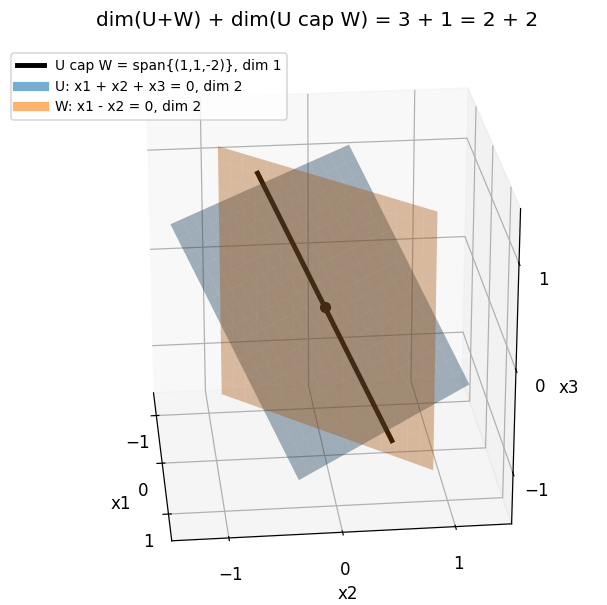

check: the intersection direction satisfies both defining equations
  x1 + x2 + x3 = 0.0
  x1 - x2      = 0.0


In [9]:
fig = plt.figure(figsize=(7.6, 6.6))
ax = fig.add_subplot(projection="3d")

g = np.linspace(-1.25, 1.25, 18)
S, T = np.meshgrid(g, g)

# orthonormal bases of the two planes
bU = np.column_stack([np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0),
                      np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)])
bW = np.column_stack([np.array([1.0, 1.0, 0.0]) / np.sqrt(2.0),
                      np.array([0.0, 0.0, 1.0])])

PU = S[..., None] * bU[:, 0] + T[..., None] * bU[:, 1]
ax.plot_surface(PU[..., 0], PU[..., 1], PU[..., 2], alpha=0.38, color="C0",
                edgecolor="none")
PW = S[..., None] * bW[:, 0] + T[..., None] * bW[:, 1]
ax.plot_surface(PW[..., 0], PW[..., 1], PW[..., 2], alpha=0.38, color="C1",
                edgecolor="none")

d = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)
tt = np.array([-1.35, 1.35])
ax.plot(tt * d[0], tt * d[1], tt * d[2], lw=3.2, color="k",
        label="U cap W = span{(1,1,-2)}, dim 1")
ax.plot([], [], color="C0", lw=6, alpha=0.6, label="U: x1 + x2 + x3 = 0, dim 2")
ax.plot([], [], color="C1", lw=6, alpha=0.6, label="W: x1 - x2 = 0, dim 2")
ax.scatter([0], [0], [0], color="k", s=40)

for setlim, setticks in ((ax.set_xlim, ax.set_xticks),
                         (ax.set_ylim, ax.set_yticks),
                         (ax.set_zlim, ax.set_zticks)):
    setlim(-1.5, 1.5)
    setticks([-1.0, 0.0, 1.0])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("dim(U+W) + dim(U cap W) = 3 + 1 = 2 + 2")
ax.set_aspect("equal")
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(-0.06, 0.98))
ax.view_init(elev=24, azim=-6)
plt.show()

print("check: the intersection direction satisfies both defining equations")
print("  x1 + x2 + x3 =", float(np.array([1.0, 1.0, 1.0]) @ np.array([1.0, 1.0, -2.0])))
print("  x1 - x2      =", float(np.array([1.0, -1.0, 0.0]) @ np.array([1.0, 1.0, -2.0])))

The two sheets meet along the black line and nowhere else. Every direction of $\mathbb{R}^3$ is a
sum of a direction in the blue plane and one in the orange plane, but the decomposition is not
unique — the shared line can be moved from one summand to the other, which is precisely why the
sum is not direct and why the $-1$ appears in Theorem 4.6.

### 7.6 Reading dimension off the singular values

The last figure plots the singular values of the rank-two matrix from Section 7.3 against those
of its perturbed copy. Dimension is visible as a **gap**, not as a count of exact zeros.

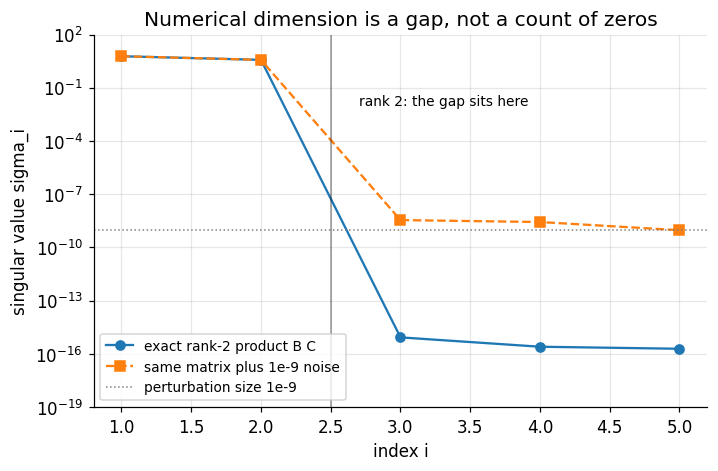

exact matrix : sigma_2 / sigma_3 = 4.342e+15
noisy matrix : sigma_2 / sigma_3 = 1.067e+09
rank read at tol = 1e-6: exact 2, noisy 2


In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
idx = np.arange(1, s_exact.size + 1)
ax.semilogy(idx, np.maximum(s_exact, 1e-20), "o-", ms=6, label="exact rank-2 product B C")
ax.semilogy(idx, s_noisy, "s--", ms=6, label="same matrix plus 1e-9 noise")
ax.axhline(1e-9, lw=1.0, color="0.5", ls=":", label="perturbation size 1e-9")
ax.axvline(2.5, lw=1.0, color="k", alpha=0.4)
ax.annotate("rank 2: the gap sits here", xy=(2.5, 1e-4), xytext=(2.7, 1e-2), fontsize=9)
ax.set_xlabel("index i")
ax.set_ylabel("singular value sigma_i")
ax.set_title("Numerical dimension is a gap, not a count of zeros")
ax.set_ylim(1e-19, 1e2)
ax.legend(fontsize=9, loc="lower left")
plt.show()

gap_exact = s_exact[1] / s_exact[2]
gap_noisy = s_noisy[1] / s_noisy[2]
print(f"exact matrix : sigma_2 / sigma_3 = {gap_exact:.3e}")
print(f"noisy matrix : sigma_2 / sigma_3 = {gap_noisy:.3e}")
print(f"rank read at tol = 1e-6: exact {np.linalg.matrix_rank(Mrank2, tol=1e-6)}, "
      f"noisy {np.linalg.matrix_rank(Mnoisy, tol=1e-6)}")
assert gap_noisy > 1e5 and gap_exact > 1e10

The exact product drops to the level of rounding after the second singular value; the perturbed
matrix drops to the level of the perturbation instead. In both cases the ratio
$\sigma_2 / \sigma_3$ is enormous, and that ratio — not the presence of exact zeros — is what
identifies $\dim \operatorname{Col}(M) = 2$.

This is the practical form of Theorem 4.2: the dimension is an invariant of the subspace, so any
sensible numerical procedure must return the same integer regardless of which basis or which
rounding path produced the matrix.

## 8. Applications

Four settings where the object of interest is a subspace, and where the useful number is its
dimension.

### 8.1 Centred data and the mean-zero subspace

Centring a data vector $x \in \mathbb{R}^n$ subtracts its mean. The centred vectors are exactly

$$
C = \lbrace x \in \mathbb{R}^n \mid \mathbf{1}^\top x = 0 \rbrace = \operatorname{Null}(\mathbf{1}^\top),
$$

a subspace by Theorem 4.3, of dimension $n-1$ by Theorem 4.7.

The centring matrix $H = I - \tfrac{1}{n}\mathbf{1}\mathbf{1}^\top$ maps $\mathbb{R}^n$ onto $C$
and satisfies $H^2 = H$. So $\mathbb{R}^n = C \oplus \operatorname{span}(\mathbf{1})$: every
data vector splits uniquely into its mean part and its centred part.

That is the reason a covariance matrix built from $m$ centred samples has rank at most
$\min(m-1, n)$, and why one degree of freedom is subtracted in the unbiased variance estimator.

### 8.2 Feature spaces, collinearity and the null space of a design matrix

For a design matrix $X \in \mathbb{R}^{m \times n}$ the hypothesis space of a linear model is
$\operatorname{Col}(X)$, and its dimension is $\operatorname{rank}(X)$ — the number of genuinely
distinct features.

If two features are collinear then $\operatorname{Null}(X) \neq \lbrace 0 \rbrace$, and by
Theorem 4.7 its dimension is $n - \operatorname{rank}(X)$.

Every $\theta$ in a coset $\hat{\theta} + \operatorname{Null}(X)$ produces the identical fit
$X\theta$, so the set of optimal parameters is an affine set in the sense of Definition 3.8, and
the identifiable quantity is the coset, that is the element of the quotient
$\mathbb{R}^n / \operatorname{Null}(X)$ of Definition 3.13.

Regularisation is the standard way of choosing one representative from that coset.

### 8.3 Physics: solution spaces of linear differential equations

The map $L(y) = y'' + \omega^2 y$ is linear, so its kernel is a subspace of $C^2(\mathbb{R})$ by
Theorem 4.3.

That subspace has dimension $2$ with basis $\lbrace \cos \omega t, \sin \omega t \rbrace$, so
every free oscillation is a unique linear combination of two fundamental modes.

The physical statement "amplitude and phase are the two degrees of freedom of a harmonic
oscillator" is exactly Theorem 4.2: any other pair of independent solutions, such as
$\cos(\omega t)$ and $\cos(\omega t - \pi/3)$, is also a basis and must also have length $2$.

Superposition — the principle that two solutions add to a solution — is nothing more than
closure under the vector-space operations.

### 8.4 Convex hulls, simplices and tensor spaces

A probability distribution over $k$ outcomes is a point of the **simplex**
$\Delta_{k-1} = \operatorname{conv}(e_1, \dots, e_k)$, whose affine hull has dimension $k-1$
because of the single constraint $\sum_i p_i = 1$. One-hot encodings are its vertices, and a
softmax output is an interior point written in barycentric coordinates.

Theorem 4.11 bounds how many vertices any such point needs: at most $k$ in $\mathbb{R}^{k-1}$,
which is why mixture representations can always be made sparse.

Tensors are the multi-linear analogue. A batch of feature maps lives in
$\mathbb{R}^{B} \otimes \mathbb{R}^{C} \otimes \mathbb{R}^{H} \otimes \mathbb{R}^{W}$, of
dimension $BCHW$ by Definition 3.15 — the parameter count of a dense layer is a dimension
computation and nothing more.

The cell below runs the three computational applications on small explicit objects: the centring
subspace, the collinear design matrix and its coset of optimal parameters, and the
two-dimensional solution space of the harmonic oscillator.

In [11]:
# --- 8.1 centring subspace ----------------------------------------------
n_ = 6
H = np.eye(n_) - np.ones((n_, n_)) / n_
print("8.1 centring")
print("   rank(H)                 :", np.linalg.matrix_rank(H), " predicted n - 1 =", n_ - 1)
print("   ||H @ H - H||_F         :", np.linalg.norm(H @ H - H))
print("   ||H @ ones||            :", np.linalg.norm(H @ np.ones(n_)))
xdat = rng.standard_normal(n_)
xc, xm = H @ xdat, np.ones(n_) * xdat.mean()
print("   split residual ||x - (xc + xm)|| :", np.linalg.norm(xdat - (xc + xm)))
assert np.linalg.matrix_rank(H) == n_ - 1
assert np.linalg.norm(H @ H - H) < 1e-12
assert np.linalg.norm(xdat - (xc + xm)) < 1e-12

# --- 8.2 collinear features ---------------------------------------------
f1 = rng.standard_normal(40)
f2 = rng.standard_normal(40)
X = np.column_stack([f1, f2, 2.0 * f1 - 3.0 * f2])       # third feature is redundant
y = 1.5 * f1 - 0.5 * f2
rk = np.linalg.matrix_rank(X)
Nx = null_space(X)
theta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
theta_alt = theta_hat + 0.7 * Nx[:, 0]
print("\n8.2 collinear design matrix")
print("   n = 3 features, rank(X) =", rk, "  dim Null(X) =", Nx.shape[1],
      "  rank + nullity =", rk + Nx.shape[1])
print("   null direction          :", Nx[:, 0] / Nx[0, 0])
print("   two parameter vectors   :", theta_hat, theta_alt)
print("   ||X theta_hat - X theta_alt|| :", np.linalg.norm(X @ theta_hat - X @ theta_alt))
assert rk + Nx.shape[1] == X.shape[1]
assert np.linalg.norm(X @ theta_hat - X @ theta_alt) < 1e-10

# --- 8.3 harmonic oscillator --------------------------------------------
omega = 2.0
t = np.linspace(0.0, 3.0, 400)
Y = np.column_stack([np.cos(omega * t), np.sin(omega * t),
                     np.cos(omega * t - np.pi / 3)])
print("\n8.3 solution space of y'' + omega^2 y = 0")
print("   rank[cos, sin, cos(.-pi/3)] :", np.linalg.matrix_rank(Y), " predicted 2")
cshift = np.linalg.lstsq(Y[:, :2], Y[:, 2], rcond=None)[0]
print("   cos(wt - pi/3) = %.6f cos(wt) + %.6f sin(wt)" % (cshift[0], cshift[1]))
print("   exact (cos 60 deg, sin 60 deg) :", np.cos(np.pi / 3), np.sin(np.pi / 3))
print("   residual                     :",
      np.linalg.norm(Y[:, :2] @ cshift - Y[:, 2]))
assert np.linalg.matrix_rank(Y) == 2
assert np.allclose(cshift, [np.cos(np.pi / 3), np.sin(np.pi / 3)], atol=1e-8)

8.1 centring
   rank(H)                 : 5  predicted n - 1 = 5
   ||H @ H - H||_F         : 2.6910028968576024e-16
   ||H @ ones||            : 2.7194799110210365e-16
   split residual ||x - (xc + xm)|| : 1.4833660915169986e-16

8.2 collinear design matrix
   n = 3 features, rank(X) = 2   dim Null(X) = 1   rank + nullity = 3
   null direction          : [ 1.  -1.5 -0.5]
   two parameter vectors   : [0.8571 0.4643 0.3214] [ 1.2313 -0.097   0.1343]
   ||X theta_hat - X theta_alt|| : 4.227922206691567e-15

8.3 solution space of y'' + omega^2 y = 0
   rank[cos, sin, cos(.-pi/3)] : 2  predicted 2
   cos(wt - pi/3) = 0.500000 cos(wt) + 0.866025 sin(wt)
   exact (cos 60 deg, sin 60 deg) : 0.5000000000000001 0.8660254037844386
   residual                     : 3.659034690639708e-15


The centring matrix has rank $n-1$, is idempotent, and annihilates the all-ones vector: it is the
projection onto the mean-zero subspace, and the split of a data vector is exact.

The design matrix has three columns but rank $2$, so its null space is one-dimensional. Two
parameter vectors differing by a null direction produce identical predictions — the fit sees only
the coset, exactly as Section 8.2 claims.

The third experiment recovers the phase-shift identity
$\cos(\omega t - \pi/3) = \tfrac{1}{2}\cos \omega t + \tfrac{\sqrt3}{2}\sin \omega t$ to eight
digits, which is the concrete meaning of "the solution space has dimension two".

## 9. Key Takeaways

- **Steinitz bounds independence by spanning.** If $m$ vectors are independent and $n$ vectors
  span, then $m \le n$ (Theorem 4.1). Both lists must be finite; nothing else is assumed.

- **Dimension is well defined.** Every basis of a finite-dimensional space has the same length
  (Theorem 4.2), so rank, nullity, codimension and "number of degrees of freedom" are invariants
  of the space rather than artefacts of a chosen basis.

- **Subspace-hood costs two checks.** $0 \in U$ together with $\alpha u + v \in U$ is equivalent
  to all eight axioms (Theorem 4.3). Closure under scaling alone is strictly weaker, as
  $\lbrace xy \ge 0 \rbrace$ shows in Section 7.3.

- **Bases can always be built from either side.** Any independent list extends to a basis and any
  spanning list contains one (Theorem 4.4), so every subspace has a complement — never unique
  except in the trivial cases.

- **Dimensions obey inclusion-exclusion.**
  $\dim(U+W) + \dim(U \cap W) = \dim U + \dim W$ (Theorem 4.6), and the sum is direct exactly when
  the intersection term vanishes.

- **Rank plus nullity equals the number of columns**, and row rank equals column rank
  (Theorem 4.7). One independent linear constraint costs exactly one dimension, which is what
  makes $\dim(V/U) = \dim V - \dim U$ (Theorem 4.8) and
  $\dim U + \dim U^{0} = \dim V$ (Theorem 4.10) the same statement in three costumes.

- **Every $n$-dimensional space over $\mathbb{F}$ is $\mathbb{F}^n$ in disguise** (Theorem 4.9),
  and the double dual is canonically the space itself. The field must be named: $\mathbb{C}$ has
  dimension $1$ over itself and $2$ over $\mathbb{R}$.

- **Convex combinations never need more than $n+1$ points** in $\mathbb{R}^n$ (Theorem 4.11), the
  affine counterpart of the linear dimension bound.

- **Numerically, dimension is a gap and not a count of zeros.** A rank-two matrix perturbed by
  $10^{-9}$ has no zero singular values at all (Section 7.3), and random vectors stay independent
  while their margin shrinks like $n^{-1/2}$ (Section 7.4, observed slope against the predicted
  $-0.5$).

## 10. References

**Textbooks.**

- Axler, S. *Linear Algebra Done Right*, 3rd ed. — section 1.C (subspaces and sums), section 2.A
  (span and independence, Theorem 2.23: the length of an independent list is at most the length of
  a spanning list), section 2.C (dimension and Theorem 2.43, the dimension of a sum), section 3.E
  (products and quotients), section 3.F (duality, dual bases and annihilators).
- Halmos, P. R. *Finite-Dimensional Vector Spaces*, 2nd ed. — sections 5 to 8 (dependence, bases,
  dimension), sections 10 to 12 (subspaces and the dimension of a subspace), sections 13 to 17
  (dual spaces, dual bases, reflexivity, annihilators), sections 18 to 22 (direct sums and
  quotient spaces).
- Halmos, P. R. *Naive Set Theory*, section 16 — Zorn's lemma, the set-theoretic input to
  Theorem 4.13.
- Strang, G. *Linear Algebra and Learning from Data*, section I.3 — the four fundamental subspaces
  and the rank identities of Theorem 4.7 read off a factorization $A = CR$.
- Boyd, S. and Vandenberghe, L. *Introduction to Applied Linear Algebra*, chapter 1 (vectors) and
  chapter 5 (linear independence, basis, and the independence-dimension inequality, which is
  Theorem 4.1 in this module).
- Horn, R. A. and Johnson, C. R. *Matrix Analysis*, 2nd ed., section 0.1 (vector spaces,
  subspaces, span, independence, basis) and section 0.4 (rank and the rank identities).
- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra*, Lecture 1 (range, null space and rank)
  and Lecture 5 (the SVD, rank and numerical rank — the tolerance question of Section 7.3).
- Rockafellar, R. T. *Convex Analysis*, section 2 (affine sets and affine hulls) and section 17
  (Theorem 17.1, Caratheodory's theorem, proved here as Proof 5.11).
- Boyd, S. and Vandenberghe, L. *Convex Optimization*, section 2.1 — affine and convex sets,
  hulls, and the simplex used in Section 8.4.

**Papers.**

- Edelman, A. "Eigenvalues and condition numbers of random matrices", *SIAM Journal on Matrix
  Analysis and Applications* **9**(4) (1988), 543-560 — the $n^{-1/2}$ scaling of
  $\sigma_{\min}$ measured in Section 7.4.
- Blass, A. "Existence of bases implies the axiom of choice", *Contemporary Mathematics* **31**
  (1984), 31-33 — the converse direction referred to in Theorem 4.13.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Proof techniques used throughout Section 5 — induction, contradiction, double inclusion:
  [mathematical_reasoning/03](../../mathematical_reasoning/03_proof_techniques/).
- Sets, relations and functions, assumed in Definition 3.10:
  [mathematical_reasoning/02](../../mathematical_reasoning/02_sets_relations_and_functions/).
- The general theory of linear maps, of which Definition 3.10 and Theorem 4.7 are the first
  instalment: [Module 02](../02_linear_maps_and_matrix_transformations/first_principles.ipynb).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).